In [1]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
import pandas as pd
df = pd.read_csv('purchase_data_exe.csv')  # thay bằng tên thật của file bạn vừa upload
df.head()

,date,customer_id,product_category,payment_method,value [USD],time_on_site [Minutes],clicks_in_site
0,20/11/2018,37077,505,credit,49.53,12.0,8
1,20/11/2018,59173,509,paypal,50.61,25.9,8
2,20/11/2018,41066,507,credit,85.99,34.9,11
3,20/11/2018,50741,506,credit,34.60,16.5,9
4,20/11/2018,53639,515,paypal,266.27,43.1,30


# Mục mới

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24999 entries, 0 to 24998
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    24999 non-null  object 
 1   customer_id             24999 non-null  int64  
 2   product_category        24999 non-null  int64  
 3   payment_method          24999 non-null  object 
 4   value [USD]             24999 non-null  float64
 5   time_on_site [Minutes]  24999 non-null  float64
 6   clicks_in_site          24999 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.3+ MB


In [4]:
print(f"{df.shape}")

(24999, 7)


In [5]:
df = df.rename(columns={'value [USD]': 'value'})

In [6]:
df = df.rename(columns={'time_on_site [Minutes]': 'time_on_site'})

In [7]:
df = df.rename(columns={'clicks_in_site': 'clicks'})

In [8]:
df.columns

Index(['date', 'customer_id', 'product_category', 'payment_method', 'value',
       'time_on_site', 'clicks'],
      dtype='object')

In [9]:
#Check Null Value
df.isna().sum().sum()

np.int64(0)

In [10]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [11]:
num_cols =  df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

In [12]:
print(f"categorical columns : {cat_cols}")
print(f"numerical columns : {num_cols}")

categorical columns : ['date', 'payment_method']
numerical columns : ['customer_id', 'product_category', 'value', 'time_on_site', 'clicks']


In [13]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,24999.0,35047.126765,14448.792961,10000.0,22500.00,35184.00,47468.000,59998.00
product_category,24999.0,507.918797,4.288552,501.0,504.00,508.00,512.000,515.00
value,24999.0,203.248763,208.015747,0.0,57.17,136.72,278.815,2177.04
time_on_site,24999.0,73.132649,150.983919,2.0,13.30,24.10,43.000,655.00
clicks,24999.0,16.039642,13.396365,0.0,8.00,11.00,19.000,167.00


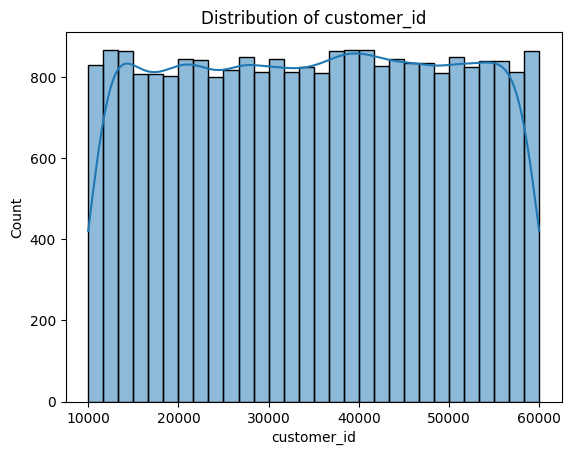

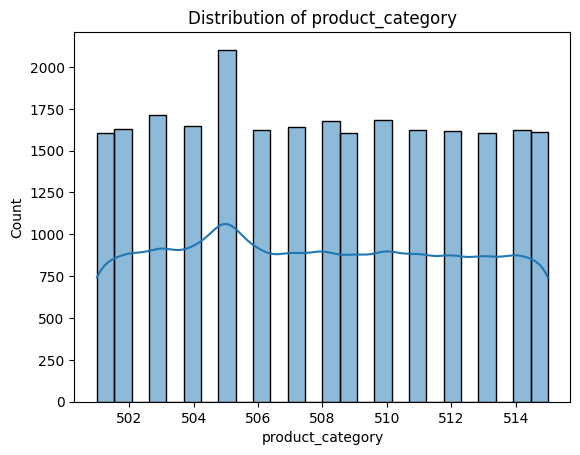

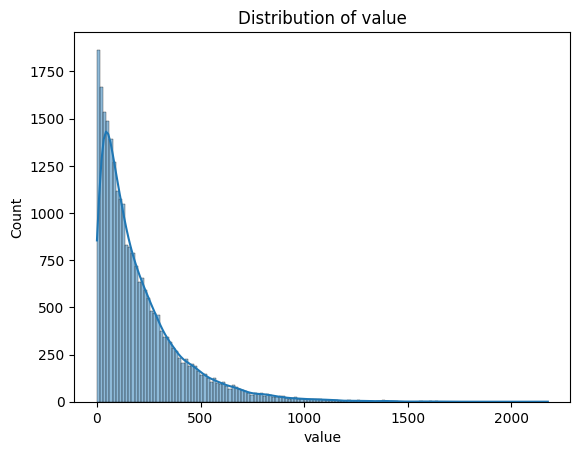

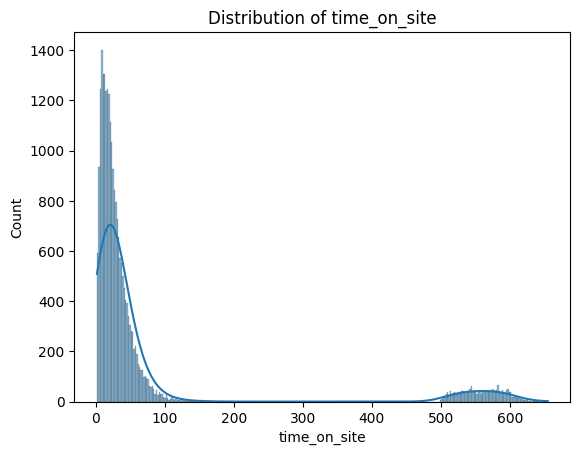

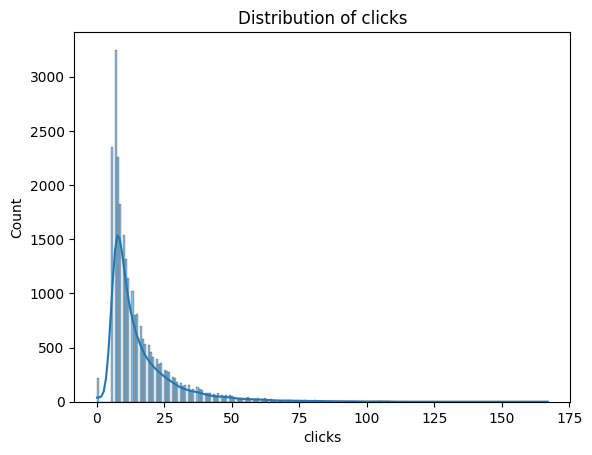

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


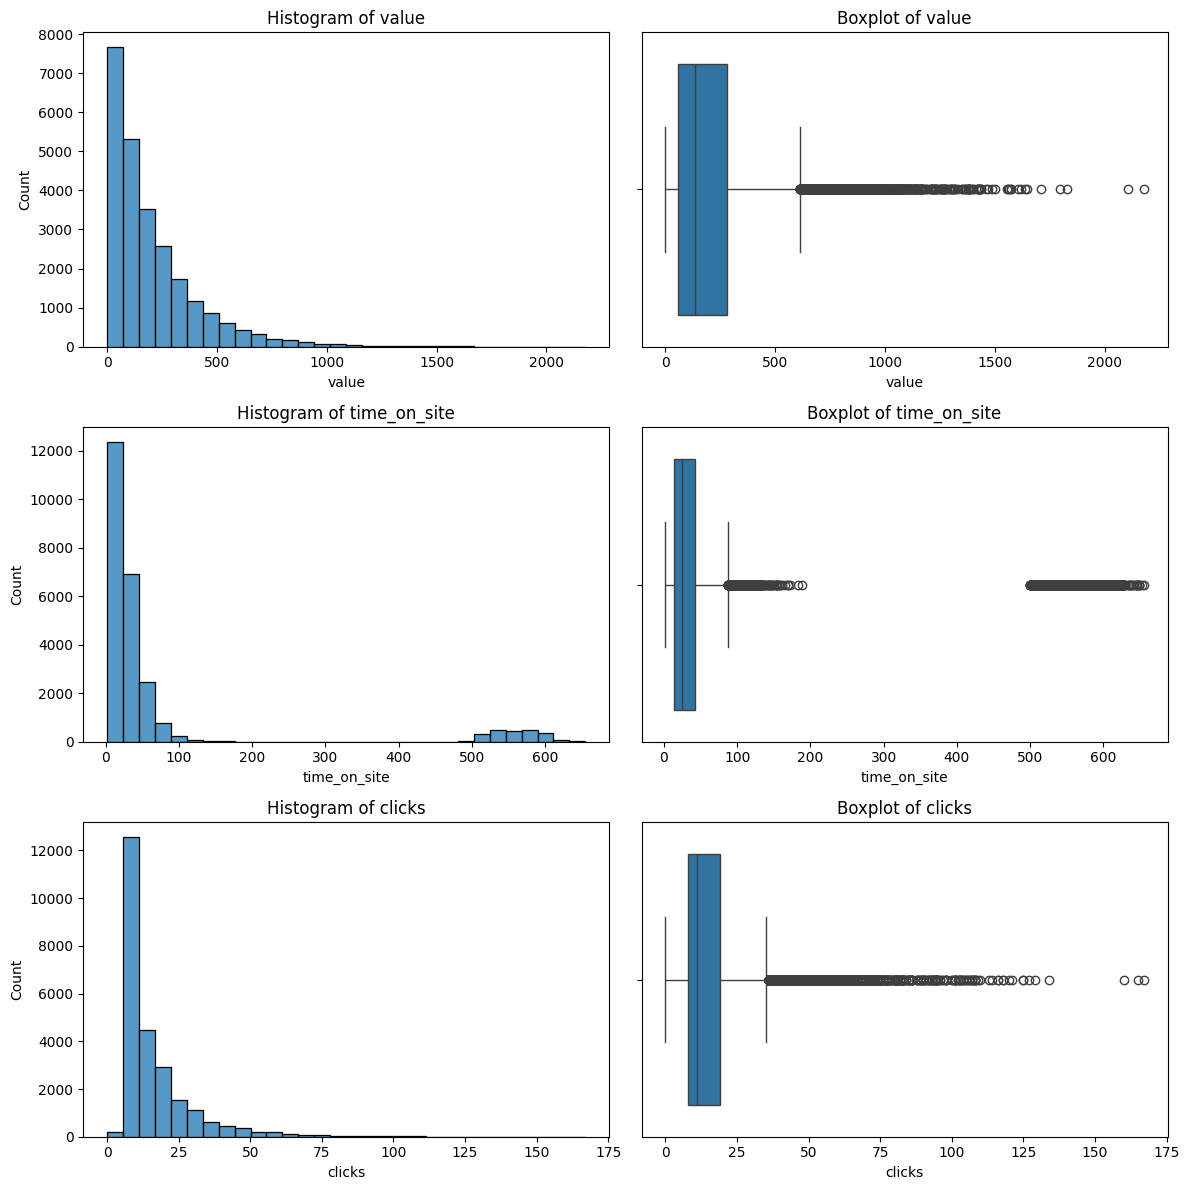

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các biến cần vẽ
cols = ['value', 'time_on_site', 'clicks']

# Tạo khung vẽ 3 hàng, 2 cột (mỗi biến có 2 biểu đồ)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for i, col in enumerate(cols):
    # Histogram
    sns.histplot(df[col], bins=30, ax=axes[i, 0], kde=False)
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

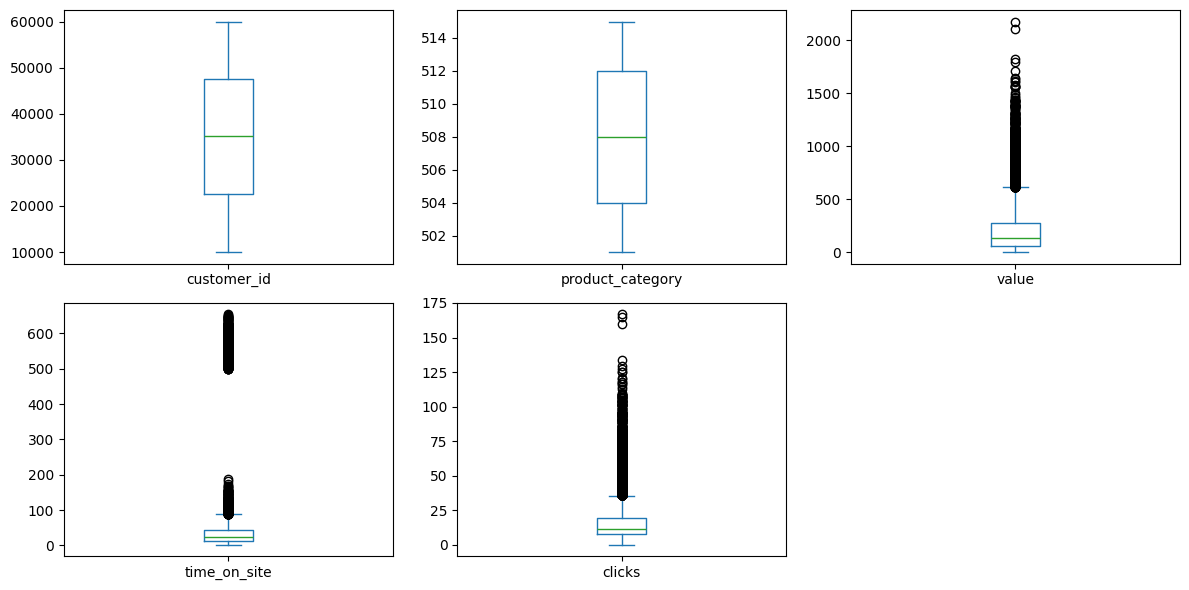

In [16]:
df.plot(kind='box', figsize=(12, 6), subplots=True, layout=(2, 3), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

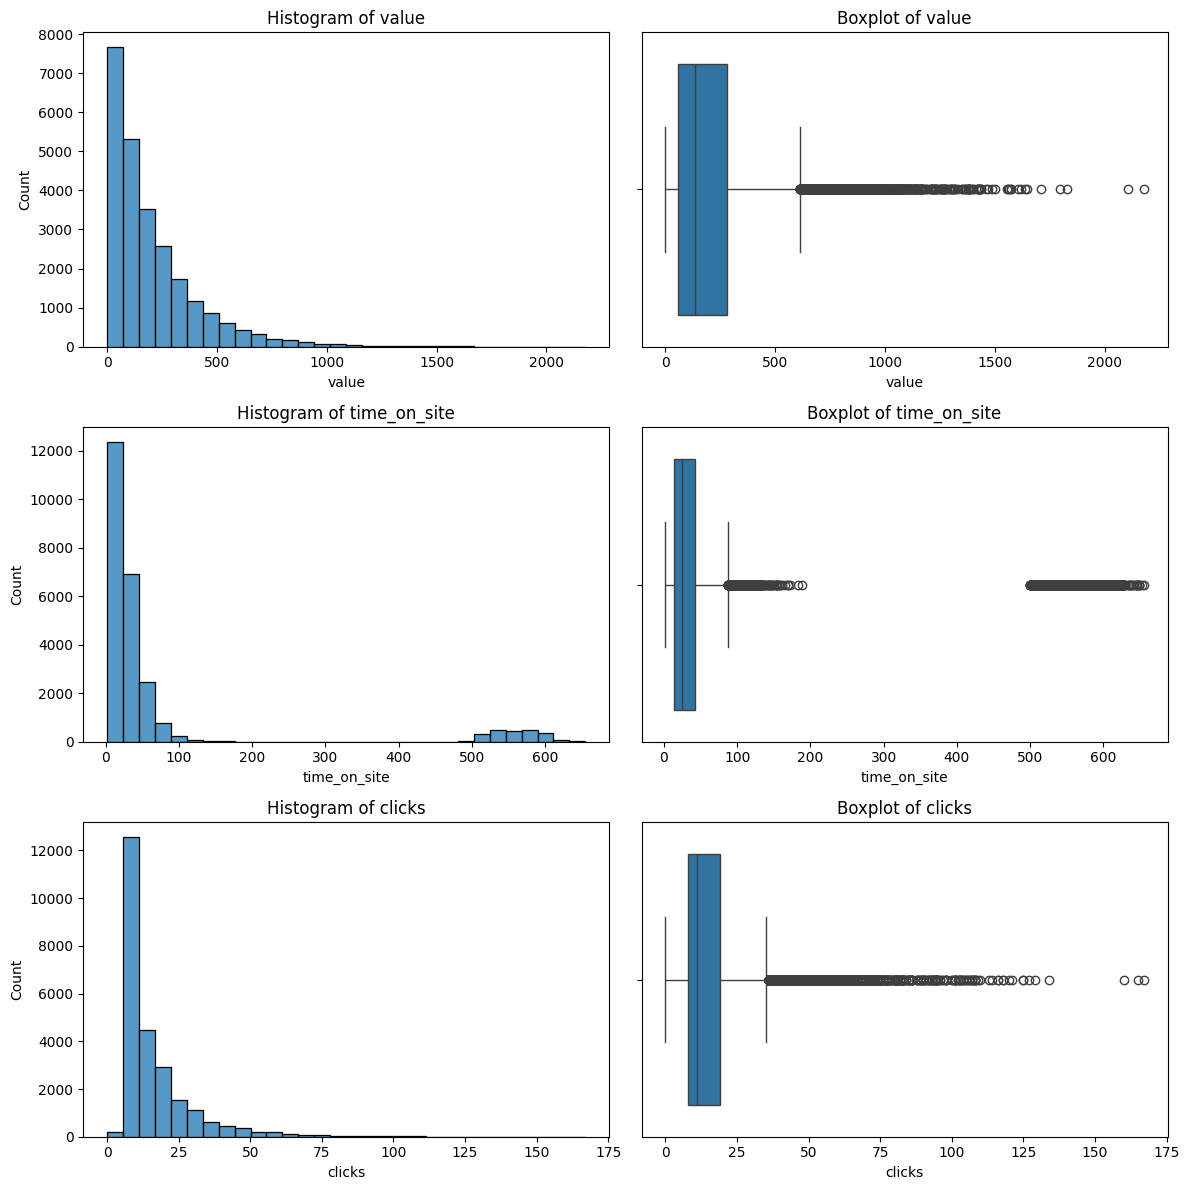

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các biến cần vẽ
cols = ['value', 'time_on_site', 'clicks']

# Tạo khung vẽ 3 hàng, 2 cột (mỗi biến có 2 biểu đồ)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for i, col in enumerate(cols):
    # Histogram
    sns.histplot(df[col], bins=30, ax=axes[i, 0], kde=False)
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

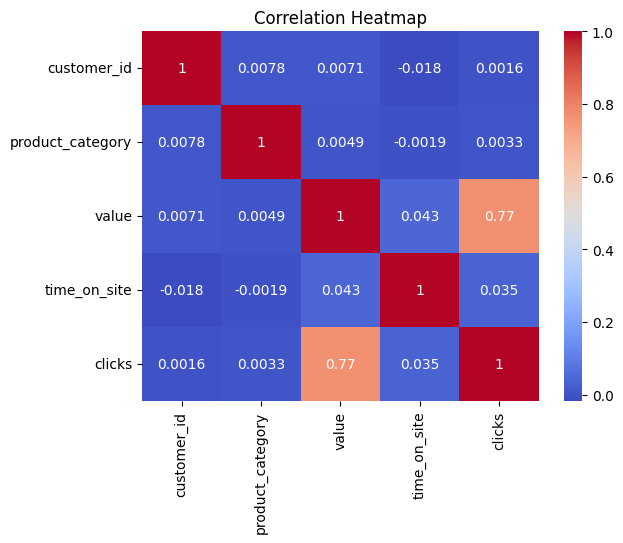

In [18]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

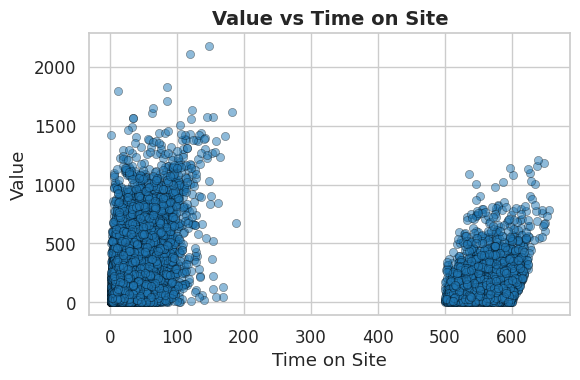

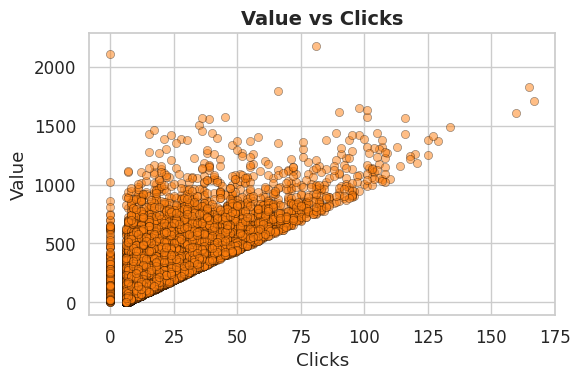

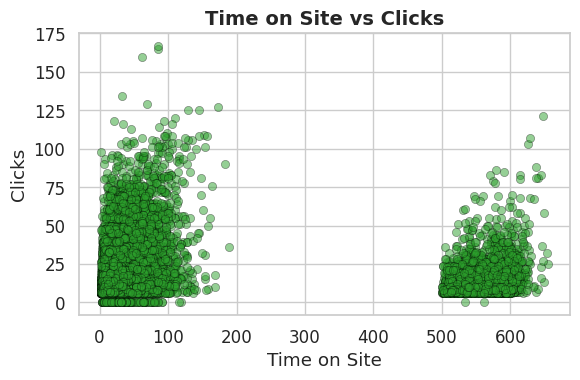

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình style tổng thể
sns.set(style="whitegrid", font_scale=1.1)

# Scatter plot: value vs time_on_site
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='time_on_site', y='value', data=df,
    color='#1f77b4', s=35, alpha=0.5, edgecolor='black', linewidth=0.4
)
plt.title('Value vs Time on Site', fontsize=14, fontweight='bold')
plt.xlabel('Time on Site')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

# Scatter plot: value vs clicks
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='clicks', y='value', data=df,
    color='#ff7f0e', s=35, alpha=0.5, edgecolor='black', linewidth=0.4
)
plt.title('Value vs Clicks', fontsize=14, fontweight='bold')
plt.xlabel('Clicks')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

# Scatter plot: time_on_site vs clicks
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='time_on_site', y='clicks', data=df,
    color='#2ca02c', s=35, alpha=0.5, edgecolor='black', linewidth=0.4
)
plt.title('Time on Site vs Clicks', fontsize=14, fontweight='bold')
plt.xlabel('Time on Site')
plt.ylabel('Clicks')
plt.tight_layout()
plt.show()


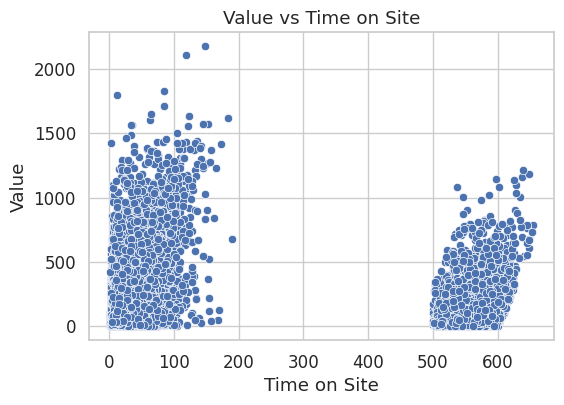

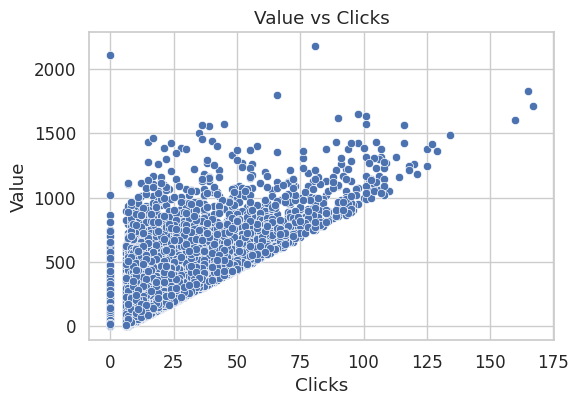

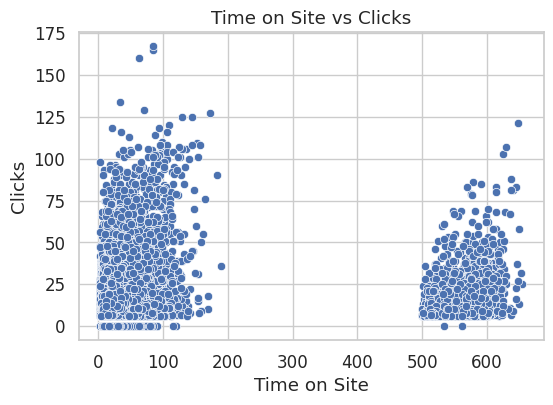

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: value vs time_on_site
plt.figure(figsize=(6, 4))
sns.scatterplot(x='time_on_site', y='value', data=df)
plt.title('Value vs Time on Site')
plt.xlabel('Time on Site')
plt.ylabel('Value')
plt.show()

# Scatter plot: value vs clicks
plt.figure(figsize=(6, 4))
sns.scatterplot(x='clicks', y='value', data=df)
plt.title('Value vs Clicks')
plt.xlabel('Clicks')
plt.ylabel('Value')
plt.show()

# Scatter plot: time_on_site vs clicks
plt.figure(figsize=(6, 4))
sns.scatterplot(x='time_on_site', y='clicks', data=df)
plt.title('Time on Site vs Clicks')
plt.xlabel('Time on Site')
plt.ylabel('Clicks')
plt.show()

In [21]:
count_zero_clicks = (df['clicks'] == 0).sum()
count_zero_clicks

np.int64(215)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24999 entries, 0 to 24998
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              24999 non-null  object 
 1   customer_id       24999 non-null  int64  
 2   product_category  24999 non-null  int64  
 3   payment_method    24999 non-null  object 
 4   value             24999 non-null  float64
 5   time_on_site      24999 non-null  float64
 6   clicks            24999 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.3+ MB


In [23]:
df_zero_clicks = df[df['clicks'] == 0]

# In ra các dòng đã được lọc
print(df_zero_clicks)

             date  customer_id  product_category payment_method   value  \
16     20/11/2018        57057               503         paypal    8.86   
20     20/11/2018        14449               514         paypal  234.70   
27     20/11/2018        26058               504         credit   56.20   
106    20/11/2018        31526               515         credit  339.09   
108    20/11/2018        18701               515         paypal   49.22   
...           ...          ...               ...            ...     ...   
18213  26/11/2018        49211               510         credit  529.60   
18214  26/11/2018        45897               503         credit  148.94   
18216  26/11/2018        37536               501         credit   21.40   
21230  28/11/2018        15062               504         paypal  142.13   
21235  28/11/2018        35088               510         paypal   16.27   

       time_on_site  clicks  
16             38.1       0  
20             24.8       0  
27       

In [24]:
df = df[df['clicks'] != 0]

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24784 entries, 0 to 24998
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              24784 non-null  object 
 1   customer_id       24784 non-null  int64  
 2   product_category  24784 non-null  int64  
 3   payment_method    24784 non-null  object 
 4   value             24784 non-null  float64
 5   time_on_site      24784 non-null  float64
 6   clicks            24784 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.5+ MB


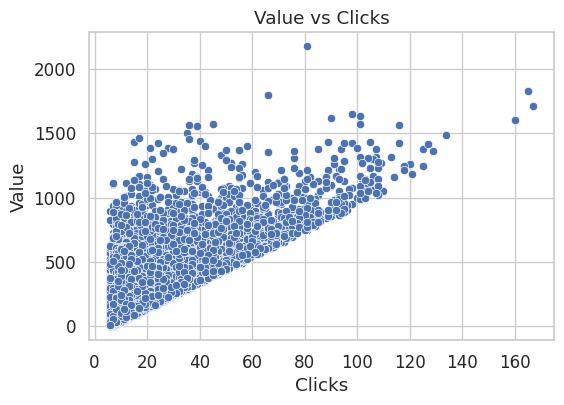

In [26]:
# Scatter plot: value vs clicks
plt.figure(figsize=(6, 4))
sns.scatterplot(x='clicks', y='value', data=df)
plt.title('Value vs Clicks')
plt.xlabel('Clicks')
plt.ylabel('Value')
plt.show()

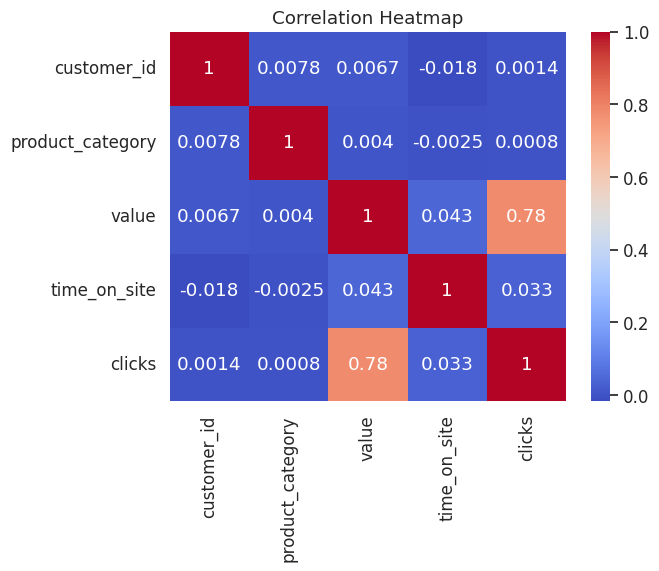

In [27]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [28]:
tong_tien = df.groupby('customer_id')['value'].sum().reset_index()
tong_tien.head()

,customer_id,value
0,10000,694.07
1,10002,164.28
2,10004,186.92
3,10006,156.63
4,10013,705.40


In [29]:
import pandas as pd

# Giả sử df có các cột: date, customer_id, value [USD]
# Đảm bảo cột date ở dạng datetime
df['date'] = pd.to_datetime(df['date'])

# Frequency – số lần xuất hiện (số giao dịch) của mỗi khách hàng
frequency = df.groupby('customer_id').size().reset_index(name='Frequency')

# Monetary – tổng giá trị chi tiêu của khách hàng
monetary = df.groupby('customer_id')['value'].sum().reset_index(name='Monetary')

# Lấy ngày mới nhất trong toàn bộ dữ liệu (ví dụ hôm nay)
max_date = df['date'].max()

# Tính số ngày kể từ lần mua gần nhất của mỗi khách hàng đến ngày hiện tại
recency = (
    df.groupby('customer_id')['date']
      .max()
      .reset_index()
      .rename(columns={'date': 'last_purchase_date'})
)

# Nếu khách hàng mua hôm nay => Recency = 0
recency['Recency'] = (max_date - recency['last_purchase_date']).dt.days

recency = recency[['customer_id', 'Recency']]


# Giữ lại các cột cần thiết
recency = recency[['customer_id', 'Recency']]

# Gộp 3 bảng lại thành 1
aggregated_df = frequency.merge(monetary, on='customer_id').merge(recency, on='customer_id')

# Xem kết quả
print(aggregated_df.head(1000))


     customer_id  Frequency  Monetary  Recency
0          10000          2    694.07        1
1          10002          1    164.28        3
2          10004          1    186.92        4
3          10006          2    156.63        2
4          10013          1    705.40        1
..           ...        ...       ...      ...
995        12487          1    246.65        8
996        12489          2    460.89        3
997        12492          1     84.75        2
998        12493          1      8.55        0
999        12494          2    187.64        1

[1000 rows x 4 columns]


In [30]:
aggregated_df.head(5)

,customer_id,Frequency,Monetary,Recency
0,10000,2,694.07,1
1,10002,1,164.28,3
2,10004,1,186.92,4
3,10006,2,156.63,2
4,10013,1,705.40,1


In [31]:
aggregated_df.describe()

,customer_id,Frequency,Monetary,Recency
count,19646.000000,19646.000000,19646.000000,19646.000000
mean,35006.093251,1.261529,256.282003,4.390207
std,14469.639733,0.526724,256.570388,2.756687
min,10000.000000,1.000000,0.000000,0.000000
25%,22443.250000,1.000000,72.435000,2.000000
50%,35139.500000,1.000000,179.100000,5.000000
75%,47465.000000,1.000000,355.150000,6.000000
max,59998.000000,5.000000,2668.120000,9.000000


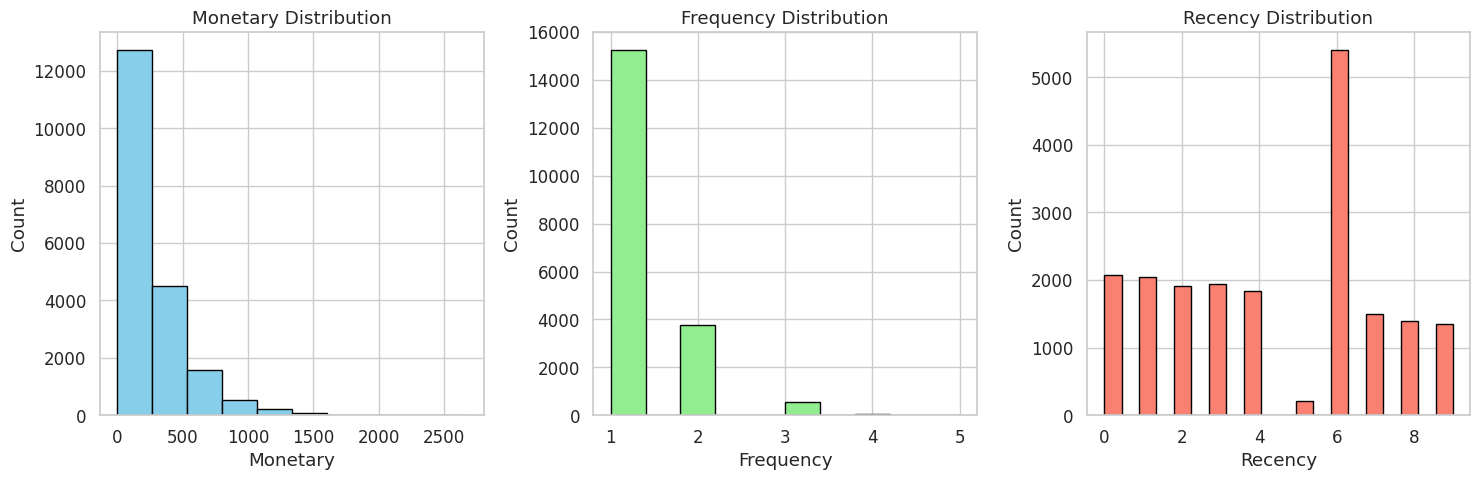

In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['Monetary'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Distribution')
plt.xlabel('Monetary')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

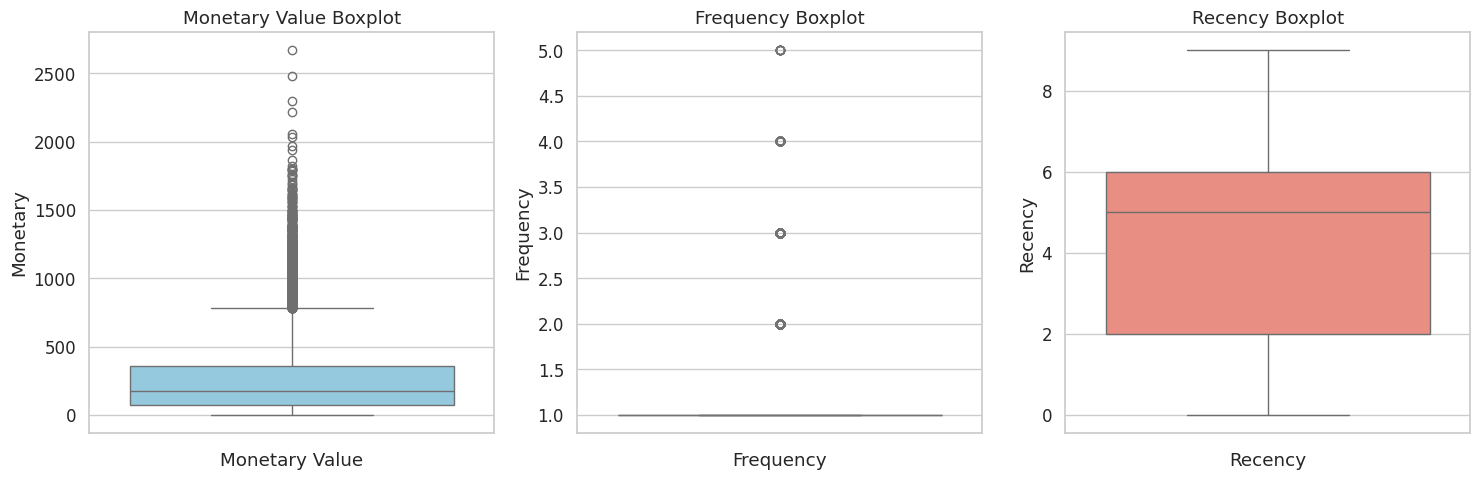

In [33]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['Monetary'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

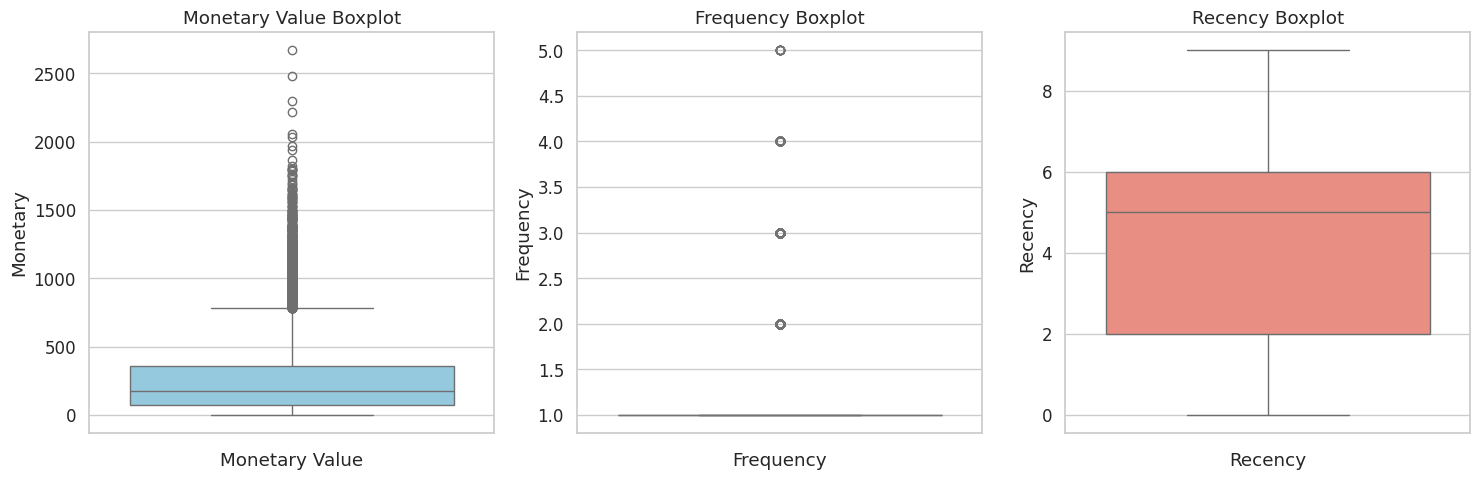

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['Monetary'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()


In [35]:
rfm = aggregated_df.copy()

In [36]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,19646.0,35006.093251,14469.639733,10000.0,22443.250,35139.5,47465.00,59998.00
Frequency,19646.0,1.261529,0.526724,1.0,1.000,1.0,1.00,5.00
Monetary,19646.0,256.282003,256.570388,0.0,72.435,179.1,355.15,2668.12
Recency,19646.0,4.390207,2.756687,0.0,2.000,5.0,6.00,9.00


In [37]:
rfm_scores = rfm.copy()

In [38]:
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency
0,10000,2,694.07,1
1,10002,1,164.28,3
2,10004,1,186.92,4
3,10006,2,156.63,2
4,10013,1,705.40,1


In [39]:
#Date from customer's last purchase.The nearest date gets 5 and the furthest date gets 1.
rfm_scores['Recency_Score'] = pd.qcut(rfm_scores['Recency'],5,labels=[5,4,3,2,1])
# Total number of purchases.The least frequency gets 1 and the maximum frequency gets 5.
rfm_scores['Frequency_Score'] = pd.qcut(rfm_scores['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
#Total spend by the customer.The least money gets 1, the most money gets 5.
rfm_scores['Monetary_Score'] = pd.qcut(rfm_scores['Monetary'],5,labels=[1,2,3,4,5])

In [40]:
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score
0,10000,2,694.07,1,5,4,5
1,10002,1,164.28,3,4,1,3
2,10004,1,186.92,4,3,1,3
3,10006,2,156.63,2,4,4,3
4,10013,1,705.40,1,5,1,5


In [41]:
rfm_scores['RFM_Score_Segment'] = (rfm_scores['Recency_Score'].astype(str)+rfm_scores['Frequency_Score'].astype(str)+rfm_scores['Monetary_Score'].astype(str))

In [42]:
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment
0,10000,2,694.07,1,5,4,5,545
1,10002,1,164.28,3,4,1,3,413
2,10004,1,186.92,4,3,1,3,313
3,10006,2,156.63,2,4,4,3,443
4,10013,1,705.40,1,5,1,5,515


In [43]:
rfm_scores['RFM_Score_Sum'] = rfm_scores[['Recency_Score','Frequency_Score','Monetary_Score']].sum(axis=1)

In [44]:
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum
0,10000,2,694.07,1,5,4,5,545,14
1,10002,1,164.28,3,4,1,3,413,8
2,10004,1,186.92,4,3,1,3,313,7
3,10006,2,156.63,2,4,4,3,443,11
4,10013,1,705.40,1,5,1,5,515,11


In [45]:
rfm_scores.groupby(['RFM_Score_Sum']).agg({'Recency': 'mean',
                                           'Frequency': 'mean',
                                           'Monetary': ['mean', 'count']}).round(1)

Recency Frequency Monetary      
                 mean      mean     mean count
RFM_Score_Sum                                 
3                 8.5       1.0     27.2   158
4                 8.2       1.0     51.5   450
5                 7.2       1.0     64.0   983
6                 6.4       1.0     88.1  1700
7                 5.5       1.0    120.2  2294
8                 4.7       1.0    152.6  2697
9                 4.2       1.0    224.8  2725
10                3.8       1.1    277.3  2263
11                3.5       1.3    324.9  1826
12                3.3       1.6    375.9  1571
13                3.1       2.0    519.7  1490
14                1.4       2.2    534.8   935
15                0.5       2.4    738.2   554

In [46]:
def segments(df):
    if df['RFM_Score_Sum'] > 9 :
        return 'Gold'
    elif (df['RFM_Score_Sum'] > 5) and (df['RFM_Score_Sum'] <= 9 ):
        return 'Sliver'
    else:
        return 'Bronze'

In [47]:
rfm_scores['Segment Name'] = rfm_scores.apply(segments,axis=1)

In [48]:
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name
0,10000,2,694.07,1,5,4,5,545,14,Gold
1,10002,1,164.28,3,4,1,3,413,8,Sliver
2,10004,1,186.92,4,3,1,3,313,7,Sliver
3,10006,2,156.63,2,4,4,3,443,11,Gold
4,10013,1,705.40,1,5,1,5,515,11,Gold


In [49]:
rfm_scores.groupby(['Segment Name']).agg({'Recency':'mean',
                                         'Frequency':'mean',
                                         'Monetary':['mean','count']}).round(1).sort_values(by=('Monetary','count'),
                                                                                            ascending=False)

Recency Frequency Monetary      
                mean      mean     mean count
Segment Name                                 
Sliver           5.1       1.0    154.0  9416
Gold             3.1       1.6    404.6  8639
Bronze           7.6       1.0     56.8  1591

In [50]:
# Display the top 10 segments with the most customers
rfm_scores.groupby(['RFM_Score_Segment']).size().sort_values(ascending=False)[:10]

,0
RFM_Score_Segment,
355,635
555,554
455,450
554,372
354,351
332,343
345,342
331,337
321,336


In [51]:
segment_mapping = {r'[1-2][1-2][1-5]': 'Hibernating',
                   r'[1-2][3-4][1-5]': 'At Risk',
                   r'[1-2][5][1-5]': 'Can\'t Loose',
                   r'[3][1-2][1-5]': 'About to Sleep',
                   r'[3][3][1-5]': 'Need Attention',
                   r'[3-4][4-5][1-5]': 'Loyal Customers',
                   r'[4][1][1-5]': 'Promising',
                   r'[5][1][1-5]': 'New Customers',
                   r'[4-5][2-3][1-5]': 'Potential Loyalists',
                   r'[5][4-5][1-5]': 'Champions'
                  }

In [52]:
rfm_scores['Segment'] = rfm_scores['RFM_Score_Segment'].replace(segment_mapping,regex=True)
#rfm_scores.reset_index(inplace=True)
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment
0,10000,2,694.07,1,5,4,5,545,14,Gold,Champions
1,10002,1,164.28,3,4,1,3,413,8,Sliver,Promising
2,10004,1,186.92,4,3,1,3,313,7,Sliver,About to Sleep
3,10006,2,156.63,2,4,4,3,443,11,Gold,Loyal Customers
4,10013,1,705.40,1,5,1,5,515,11,Gold,New Customers


In [53]:
rfm_scores.groupby(['Segment']).agg({"customer_id":"count"}).sort_values("customer_id",ascending=False)

,customer_id
Segment,
Loyal Customers,4634
About to Sleep,3076
Potential Loyalists,2730
Hibernating,2021
Champions,2011
At Risk,2004
Need Attention,1522
New Customers,739
Promising,694


In [54]:
rfm_scores[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count","max"]).round()

Recency           Frequency           Monetary        \
                       mean count max      mean count max     mean count   
Segment                                                                    
About to Sleep          6.0  3076   6       1.0  3076   1    235.0  3076   
At Risk                 8.0  2004   9       1.0  2004   2    185.0  2004   
Can't Loose             8.0   215   9       2.0   215   3    377.0   215   
Champions               0.0  2011   1       2.0  2011   5    369.0  2011   
Hibernating             8.0  2021   9       1.0  2021   1    182.0  2021   
Loyal Customers         4.0  4634   6       2.0  4634   5    356.0  4634   
Need Attention          6.0  1522   6       1.0  1522   1    230.0  1522   
New Customers           1.0   739   1       1.0   739   1    195.0   739   
Potential Loyalists     2.0  2730   3       1.0  2730   1    178.0  2730   
Promising               3.0   694   3       1.0   694   1    173.0   694   

                             
                        max  
Segment                      
About to Sleep       1636.0  
At Risk              1430.0  
Can't Loose          1113.0  
Champions            2219.0  
Hibernating          1554.0  
Loyal Customers      2668.0  
Need Attention       1426.0  
New Customers        1211.0  
Potential Loyalists  1795.0  
Promising             910.0

In [55]:
segment_mapping = {r'[4-5][4-5][4-5]': 'Best Customers',
                   r'[1-5][4-5][1-5]': 'Loyal Customers',
                   r'[1-5][1-5][4-5]': 'Big Spenders',
                   r'[2-3][1-5][1-5]': 'Almost Lost',
                   r'[1][1-5][1-5]': 'Lost Customers',
                   r'[4-5][1-3][1-3]': 'Recent Active Low Spender',
                  }

In [56]:
rfm_scores['Segment_New'] = rfm_scores['RFM_Score_Segment'].replace(segment_mapping,regex=True)
#rfm_scores.reset_index(inplace=True)
rfm_scores.head()

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment,Segment_New
0,10000,2,694.07,1,5,4,5,545,14,Gold,Champions,Best Customers
1,10002,1,164.28,3,4,1,3,413,8,Sliver,Promising,Recent Active Low Spender
2,10004,1,186.92,4,3,1,3,313,7,Sliver,About to Sleep,Almost Lost
3,10006,2,156.63,2,4,4,3,443,11,Gold,Loyal Customers,Loyal Customers
4,10013,1,705.40,1,5,1,5,515,11,Gold,New Customers,Big Spenders


In [57]:
rfm_scores.groupby(['Segment_New']).agg({"customer_id":"count"}).sort_values("customer_id",ascending=False)

,customer_id
Segment_New,
Loyal Customers,5689
Almost Lost,3672
Big Spenders,3633
Recent Active Low Spender,3022
Best Customers,2169
Lost Customers,1461


In [58]:
rfm.head()

,customer_id,Frequency,Monetary,Recency
0,10000,2,694.07,1
1,10002,1,164.28,3
2,10004,1,186.92,4
3,10006,2,156.63,2
4,10013,1,705.40,1


In [59]:
rfm.describe()

,customer_id,Frequency,Monetary,Recency
count,19646.000000,19646.000000,19646.000000,19646.000000
mean,35006.093251,1.261529,256.282003,4.390207
std,14469.639733,0.526724,256.570388,2.756687
min,10000.000000,1.000000,0.000000,0.000000
25%,22443.250000,1.000000,72.435000,2.000000
50%,35139.500000,1.000000,179.100000,5.000000
75%,47465.000000,1.000000,355.150000,6.000000
max,59998.000000,5.000000,2668.120000,9.000000


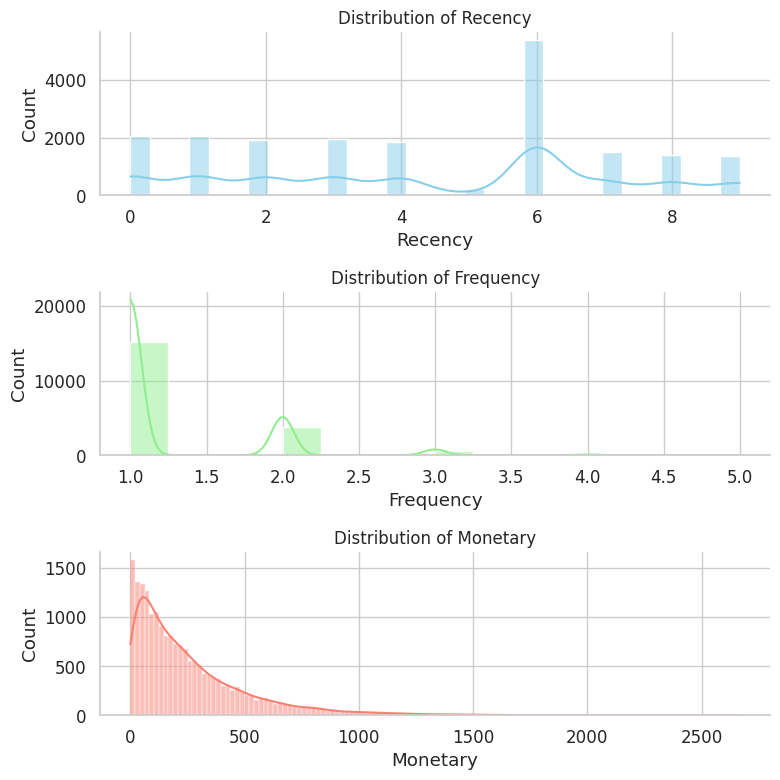

In [60]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8))

sns.despine(left=False, bottom=False)

# --- Vẽ từng biểu đồ ---
sns.histplot(rfm_scores['Recency'], ax=ax[0], kde=True, color='skyblue')
ax[0].set_title('Distribution of Recency', fontsize=12)
ax[0].set_xlabel('Recency')
ax[0].set_ylabel('Count')

sns.histplot(rfm_scores['Frequency'], ax=ax[1], kde=True, color='lightgreen')
ax[1].set_title('Distribution of Frequency', fontsize=12)
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Count')

sns.histplot(rfm_scores['Monetary'], ax=ax[2], kde=True, color='salmon')
ax[2].set_title('Distribution of Monetary', fontsize=12)
ax[2].set_xlabel('Monetary')
ax[2].set_ylabel('Count')

# --- Căn chỉnh bố cục ---
plt.tight_layout()
plt.show()


In [61]:
from scipy.stats import skew

In [62]:
skew_df = pd.DataFrame(columns=['Feature Name', 'Skewness'])

rfm_metrics = ['Recency','Frequency','Monetary']

for feature in rfm_metrics:
    skewness = skew(rfm[feature])
    skew_df = skew_df._append({'Feature Name': feature, 'Skewness': skewness}, ignore_index=True)

print(skew_df)

  Feature Name  Skewness
0      Recency -0.095024
1    Frequency  2.129915
2     Monetary  1.962972


In [63]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# --- Biến đổi Frequency bằng Yeo-Johnson ---
pt_yeojohnson_freq = PowerTransformer(method='yeo-johnson', standardize=False)
rfm['Frequency_transformed'] = pt_yeojohnson_freq.fit_transform(rfm[['Frequency']])

# --- Biến đổi Monetary bằng Yeo-Johnson ---
pt_yeojohnson_money = PowerTransformer(method='yeo-johnson', standardize=False)
rfm['Monetary_transformed'] = pt_yeojohnson_money.fit_transform(rfm[['Monetary']])

# --- Giữ nguyên Recency ---
rfm['Recency_transformed'] = rfm['Recency']

# --- Tạo bảng mới và kiểm tra skewness ---
rfm_transformed = rfm[['Recency_transformed', 'Frequency_transformed', 'Monetary_transformed']]

print("📊 Skewness sau khi biến đổi:")
print(rfm_transformed.skew().round(3))


📊 Skewness sau khi biến đổi:
Recency_transformed     -0.095
Frequency_transformed    1.322
Monetary_transformed    -0.043
dtype: float64


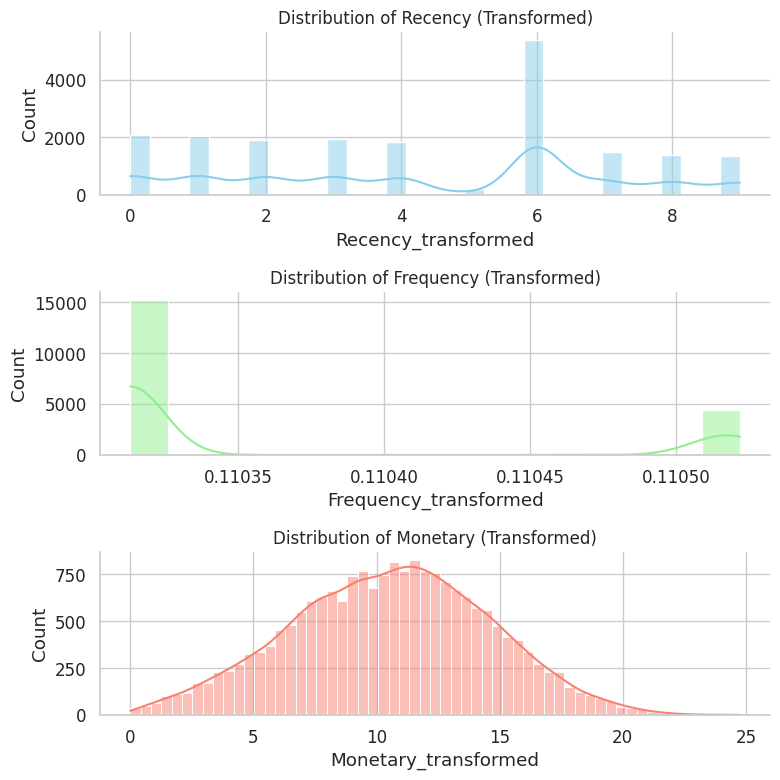

In [64]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8))

sns.despine(left=False, bottom=False)

# --- Vẽ từng biểu đồ ---
sns.histplot(rfm['Recency_transformed'], ax=ax[0], kde=True, color='skyblue')
ax[0].set_title('Distribution of Recency (Transformed)', fontsize=12)
ax[0].set_xlabel('Recency_transformed')
ax[0].set_ylabel('Count')

sns.histplot(rfm['Frequency_transformed'], ax=ax[1], kde=True, color='lightgreen')
ax[1].set_title('Distribution of Frequency (Transformed)', fontsize=12)
ax[1].set_xlabel('Frequency_transformed')
ax[1].set_ylabel('Count')

sns.histplot(rfm['Monetary_transformed'], ax=ax[2], kde=True, color='salmon')
ax[2].set_title('Distribution of Monetary (Transformed)', fontsize=12)
ax[2].set_xlabel('Monetary_transformed')
ax[2].set_ylabel('Count')

# --- Căn chỉnh bố cục ---
plt.tight_layout()
plt.show()

In [65]:
rfm_transformed.head()

,Recency_transformed,Frequency_transformed,Monetary_transformed
0,1,0.110517,16.540172
1,3,0.110313,10.342993
2,4,0.110313,10.810816
3,2,0.110517,10.174053
4,1,0.110313,16.623375


In [66]:
skew_log_transform_df = pd.DataFrame(columns=['Feature Name', 'Skewness'])

rfm_lof_transform_features = ['Frequency_transformed','Monetary_transformed']

for feature in rfm_lof_transform_features:
    skewness = skew(rfm_transformed[feature])
    skew_log_transform_df = skew_log_transform_df._append({'Feature Name': feature, 'Skewness': skewness}, ignore_index=True)

print(skew_log_transform_df)

            Feature Name  Skewness
0  Frequency_transformed  1.322126
1   Monetary_transformed -0.043006


In [67]:
rfm_transformed.head()

,Recency_transformed,Frequency_transformed,Monetary_transformed
0,1,0.110517,16.540172
1,3,0.110313,10.342993
2,4,0.110313,10.810816
3,2,0.110517,10.174053
4,1,0.110313,16.623375


In [68]:
rfm.head()

,customer_id,Frequency,Monetary,Recency,Frequency_transformed,Monetary_transformed,Recency_transformed
0,10000,2,694.07,1,0.110517,16.540172,1
1,10002,1,164.28,3,0.110313,10.342993,3
2,10004,1,186.92,4,0.110313,10.810816,4
3,10006,2,156.63,2,0.110517,10.174053,2
4,10013,1,705.40,1,0.110313,16.623375,1


In [69]:
rfm_transformed['Customer ID'] = rfm['customer_id']

In [70]:
rfm_transformed['Recency'] = rfm['Recency']

In [71]:
rfm_transformed

,Recency_transformed,Frequency_transformed,Monetary_transformed,Customer ID,Recency
0,1,0.110517,16.540172,10000,1
1,3,0.110313,10.342993,10002,3
2,4,0.110313,10.810816,10004,4
3,2,0.110517,10.174053,10006,2
4,1,0.110313,16.623375,10013,1
...,...,...,...,...,...
19641,0,0.110313,11.924072,59989,0
19642,4,0.110517,10.552503,59991,4
19643,8,0.110313,12.242435,59993,8
19644,0,0.110517,14.477016,59994,0


In [72]:
rfm_log_transform = rfm_transformed[['Customer ID','Recency','Frequency_transformed','Monetary_transformed']]

In [73]:
rfm_log_transform

,Customer ID,Recency,Frequency_transformed,Monetary_transformed
0,10000,1,0.110517,16.540172
1,10002,3,0.110313,10.342993
2,10004,4,0.110313,10.810816
3,10006,2,0.110517,10.174053
4,10013,1,0.110313,16.623375
...,...,...,...,...
19641,59989,0,0.110313,11.924072
19642,59991,4,0.110517,10.552503
19643,59993,8,0.110313,12.242435
19644,59994,0,0.110517,14.477016


In [74]:
rfm_log_transform.describe()

,Customer ID,Recency,Frequency_transformed,Monetary_transformed
count,19646.000000,19646.000000,19646.000000,19646.000000
mean,35006.093251,4.390207,0.110359,10.539525
std,14469.639733,2.756687,0.000085,4.035550
min,10000.000000,0.000000,0.110313,0.000000
25%,22443.250000,2.000000,0.110313,7.709928
50%,35139.500000,5.000000,0.110313,10.654258
75%,47465.000000,6.000000,0.110313,13.377981
max,59998.000000,9.000000,0.110522,24.754210


In [75]:
rfm_normalization = rfm_log_transform[['Recency','Frequency_transformed','Monetary_transformed']]

In [76]:
rfm_normalization

,Recency,Frequency_transformed,Monetary_transformed
0,1,0.110517,16.540172
1,3,0.110313,10.342993
2,4,0.110313,10.810816
3,2,0.110517,10.174053
4,1,0.110313,16.623375
...,...,...,...
19641,0,0.110313,11.924072
19642,4,0.110517,10.552503
19643,8,0.110313,12.242435
19644,0,0.110517,14.477016


In [77]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Replace infinite values with a small number
rfm_normalization.replace([np.inf, -np.inf], np.nan, inplace=True)
rfm_normalization.fillna(rfm_normalization.min().min(), inplace=True)

scaler = StandardScaler()
scaler.fit(rfm_normalization)
#Store it separately for clustering
rfm_normalized = scaler.transform(rfm_normalization)

In [78]:
rfm_normalized

array([[-1.22984338,  1.85093519,  1.48698445],
       [-0.5043163 , -0.53774028, -0.0487014 ],
       [-0.14155275, -0.53774028,  0.0672271 ],
       ...,
       [ 1.30950143, -0.53774028,  0.42198811],
       [-1.59260693,  1.85093519,  0.97572612],
       [ 0.94673788,  1.85093519,  0.71769909]])

In [79]:
from sklearn.cluster import KMeans

cluster_iteration = range(1,10)
scores = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    scores.append(K_Means.fit(rfm_normalized).score(rfm_normalized))

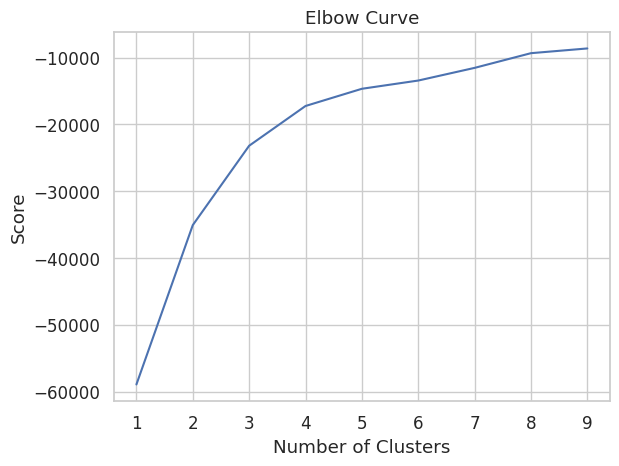

In [80]:
plt.plot(cluster_iteration,scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.xticks(cluster_iteration)
plt.style.use('ggplot')
plt.show()

In [81]:
from sklearn.cluster import KMeans

cluster_iteration = range(1,10)
inertias = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    inertias.append(K_Means.inertia_)

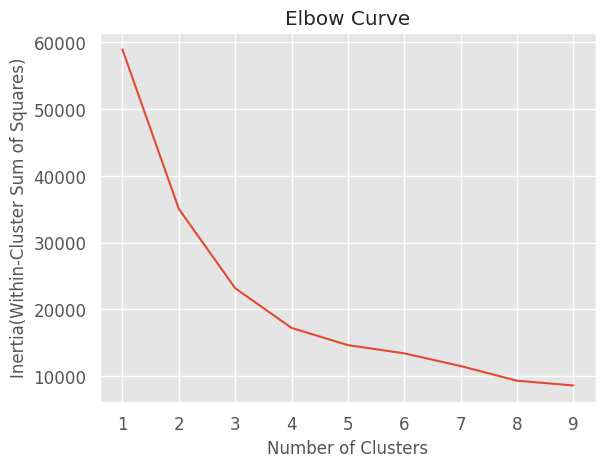

In [82]:
plt.plot(cluster_iteration,inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia(Within-Cluster Sum of Squares)')
plt.title('Elbow Curve')
plt.xticks(cluster_iteration)
plt.style.use('ggplot')
plt.show()

In [83]:
from sklearn.cluster import KMeans

cluster_iteration = range(2,10)  # Start from at least 2 clusters (Silhouette Score Requirement)
inertias = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    clustered_labels = K_Means.labels_

    silhouette_avg = silhouette_score(rfm_normalized,clustered_labels)
    print(f'For n_clusters={cluster_number}, the Silhouette score is {silhouette_avg}')

For n_clusters=2, the Silhouette score is 0.46422277856188
For n_clusters=3, the Silhouette score is 0.4198835834719079
For n_clusters=4, the Silhouette score is 0.4100159654232232
For n_clusters=5, the Silhouette score is 0.3975528324202512
For n_clusters=6, the Silhouette score is 0.39387064128761606
For n_clusters=7, the Silhouette score is 0.3578450513741132
For n_clusters=8, the Silhouette score is 0.36388517465969705
For n_clusters=9, the Silhouette score is 0.36945831223289416


In [84]:
# Clustering for final model
K_Means_final_model = KMeans(n_clusters= 4, random_state=45)
K_Means_final_model.fit(rfm_normalized)

KMeans(n_clusters=4, random_state=45)

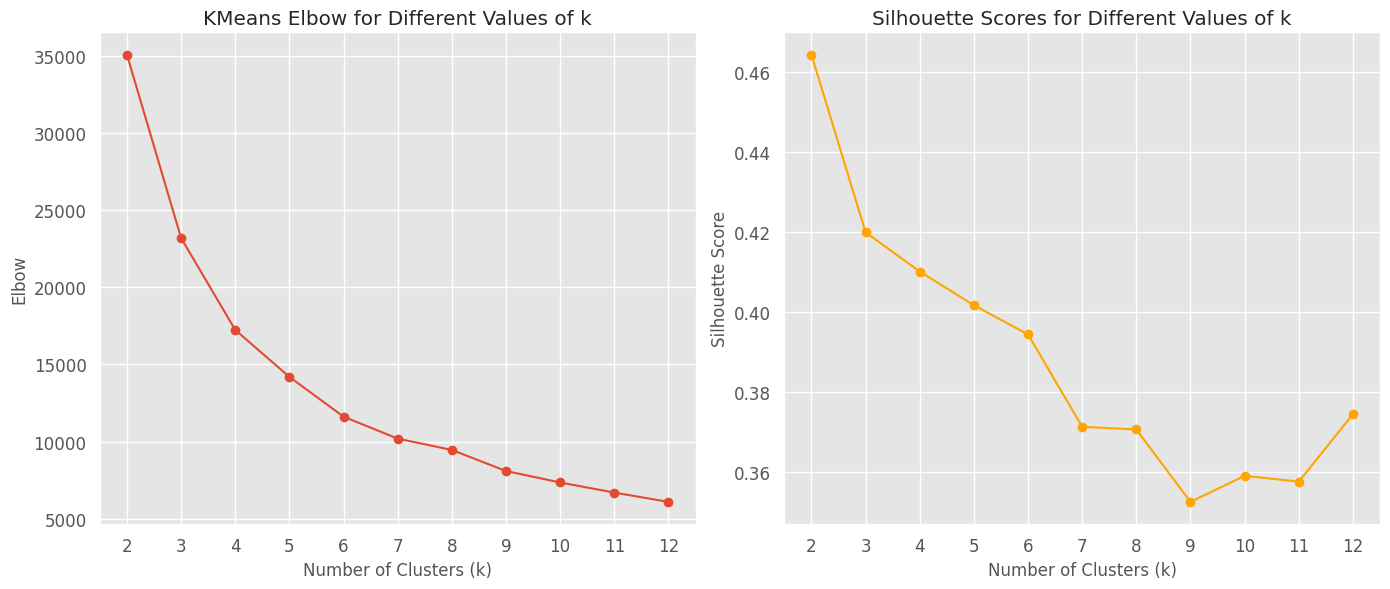

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

max_k = 12

inertia = []
silhoutte_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(rfm_normalized)

    sil_score = silhouette_score(rfm_normalized, cluster_labels)

    silhoutte_scores.append(sil_score)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Elbow for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Elbow')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [86]:
#Create a cluster label column in the original DataFrame
cluster_labels = K_Means_final_model.labels_

In [87]:
cluster_labels

array([2, 3, 3, ..., 0, 2, 2], dtype=int32)

In [88]:
rfm['Cluster'] = cluster_labels

In [89]:
rfm.head()

,customer_id,Frequency,Monetary,Recency,Frequency_transformed,Monetary_transformed,Recency_transformed,Cluster
0,10000,2,694.07,1,0.110517,16.540172,1,2
1,10002,1,164.28,3,0.110313,10.342993,3,3
2,10004,1,186.92,4,0.110313,10.810816,4,3
3,10006,2,156.63,2,0.110517,10.174053,2,2
4,10013,1,705.40,1,0.110313,16.623375,1,3


In [90]:
rfm.groupby('Cluster').agg({'Recency': 'mean',
                            'Frequency': 'mean',
                            'Monetary': ['mean', 'count'],}).round(0)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0           6.0       1.0    378.0  4998
1           7.0       1.0     59.0  4595
2           3.0       2.0    442.0  4400
3           2.0       1.0    164.0  5653

In [91]:
rfm_scores['Cluster'] = cluster_labels

In [92]:
rfm_scores

,customer_id,Frequency,Monetary,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment,Segment_New,Cluster
0,10000,2,694.07,1,5,4,5,545,14,Gold,Champions,Best Customers,2
1,10002,1,164.28,3,4,1,3,413,8,Sliver,Promising,Recent Active Low Spender,3
2,10004,1,186.92,4,3,1,3,313,7,Sliver,About to Sleep,Almost Lost,3
3,10006,2,156.63,2,4,4,3,443,11,Gold,Loyal Customers,Loyal Customers,2
4,10013,1,705.40,1,5,1,5,515,11,Gold,New Customers,Big Spenders,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19641,59989,1,250.11,0,5,4,4,544,13,Gold,Champions,Best Customers,3
19642,59991,2,174.15,4,3,5,3,353,11,Gold,Loyal Customers,Loyal Customers,2
19643,59993,1,270.80,8,1,4,4,144,9,Sliver,At Risk,Loyal Customers,0
19644,59994,2,454.15,0,5,5,5,555,15,Gold,Champions,Best Customers,2


📊 Top 10 RFM_Score_Segments with Most Customers:


,0
RFM_Score_Segment,
355,635
555,554
455,450
554,372
354,351
332,343
345,342
331,337
321,336



✅ Segment mapping applied successfully.

RFM sample with Segment:


,customer_id,RFM_Score_Segment,Segment,Recency,Frequency,Monetary
0,10000,545,Champions,1,2,694.07
1,10002,413,Promising,3,1,164.28
2,10004,313,About to Sleep,4,1,186.92
3,10006,443,Loyal Customers,2,2,156.63
4,10013,515,New Customers,1,1,705.40
5,10015,513,New Customers,0,1,191.21
6,10019,415,Promising,3,1,881.64
7,10023,111,Hibernating,9,1,49.44
8,10024,111,Hibernating,9,1,3.82
9,10026,212,Hibernating,7,1,63.46



📈 Number of customers per Segment:


,customer_id
Segment,
Loyal Customers,4634
About to Sleep,3076
Potential Loyalists,2730
Hibernating,2021
Champions,2011
At Risk,2004
Need Attention,1522
New Customers,739
Promising,694


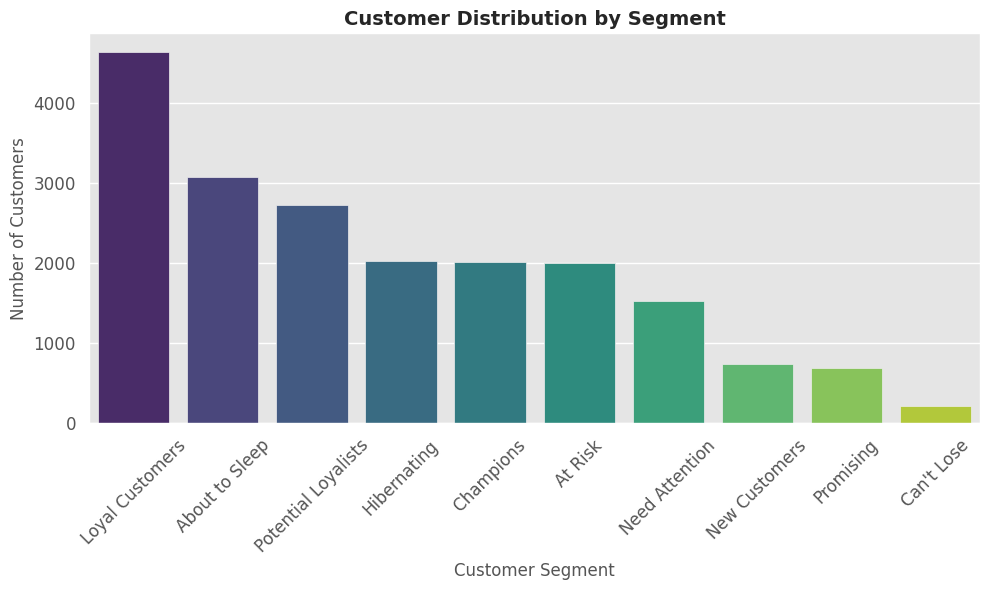


📊 Segment Performance Summary:


Recency           Frequency           Monetary        \
                       mean count max      mean count max     mean count   
Segment                                                                    
About to Sleep          6.0  3076   6       1.0  3076   1    235.0  3076   
At Risk                 8.0  2004   9       1.0  2004   2    185.0  2004   
Can't Lose              8.0   215   9       2.0   215   3    377.0   215   
Champions               0.0  2011   1       2.0  2011   5    369.0  2011   
Hibernating             8.0  2021   9       1.0  2021   1    182.0  2021   
Loyal Customers         4.0  4634   6       2.0  4634   5    356.0  4634   
Need Attention          6.0  1522   6       1.0  1522   1    230.0  1522   
New Customers           1.0   739   1       1.0   739   1    195.0   739   
Potential Loyalists     2.0  2730   3       1.0  2730   1    178.0  2730   
Promising               3.0   694   3       1.0   694   1    173.0   694   

                             
                        max  
Segment                      
About to Sleep       1636.0  
At Risk              1430.0  
Can't Lose           1113.0  
Champions            2219.0  
Hibernating          1554.0  
Loyal Customers      2668.0  
Need Attention       1426.0  
New Customers        1211.0  
Potential Loyalists  1795.0  
Promising             910.0

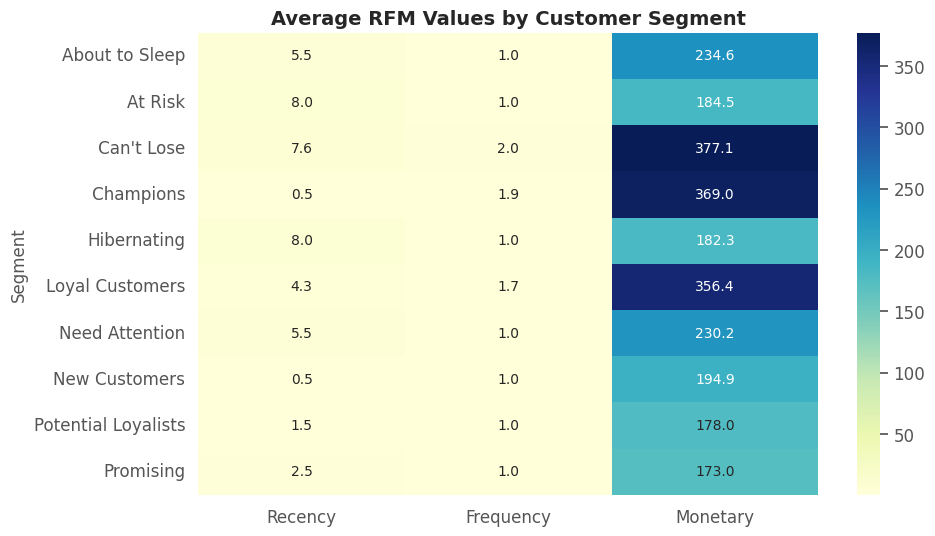

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Top 10 segments with most customers
top_segments = (
    rfm_scores.groupby(['RFM_Score_Segment'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("📊 Top 10 RFM_Score_Segments with Most Customers:")
display(top_segments)

# ✅ Segment mapping dictionary (no change)
segment_mapping = {
    r'[1-2][1-2][1-5]': 'Hibernating',
    r'[1-2][3-4][1-5]': 'At Risk',
    r'[1-2][5][1-5]': "Can't Lose",
    r'[3][1-2][1-5]': 'About to Sleep',
    r'[3][3][1-5]': 'Need Attention',
    r'[3-4][4-5][1-5]': 'Loyal Customers',
    r'[4][1][1-5]': 'Promising',
    r'[5][1][1-5]': 'New Customers',
    r'[4-5][2-3][1-5]': 'Potential Loyalists',
    r'[5][4-5][1-5]': 'Champions'
}

# ✅ Apply mapping
rfm_scores['Segment'] = rfm_scores['RFM_Score_Segment'].replace(segment_mapping, regex=True)

print("\n✅ Segment mapping applied successfully.")
print("\nRFM sample with Segment:")
display(rfm_scores[['customer_id', 'RFM_Score_Segment', 'Segment', 'Recency', 'Frequency', 'Monetary']].head(10))

# ✅ Count customers per segment
segment_counts = (
    rfm_scores.groupby(['Segment'])
    .agg({"customer_id": "count"})
    .sort_values("customer_id", ascending=False)
)

print("\n📈 Number of customers per Segment:")
display(segment_counts)

# === 🟦 Visualization 1: Bar Chart of Segments ===
plt.figure(figsize=(10,6))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts['customer_id'],
    palette="viridis"
)
plt.title("Customer Distribution by Segment", fontsize=14, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ✅ Summary statistics by segment
segment_summary = (
    rfm_scores[["Segment", "Recency", "Frequency", "Monetary"]]
    .groupby("Segment")
    .agg(["mean","count","max"])
    .round()
)

print("\n📊 Segment Performance Summary:")
display(segment_summary)

# === 🟩 Visualization 2: Heatmap of Segment Means ===
rfm_segment_avg = (
    rfm_scores.groupby('Segment')[['Recency','Frequency','Monetary']]
    .mean()
    .round(1)
)

plt.figure(figsize=(10,6))
sns.heatmap(rfm_segment_avg, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Average RFM Values by Customer Segment", fontsize=14, fontweight='bold')
plt.ylabel("Segment")
plt.show()

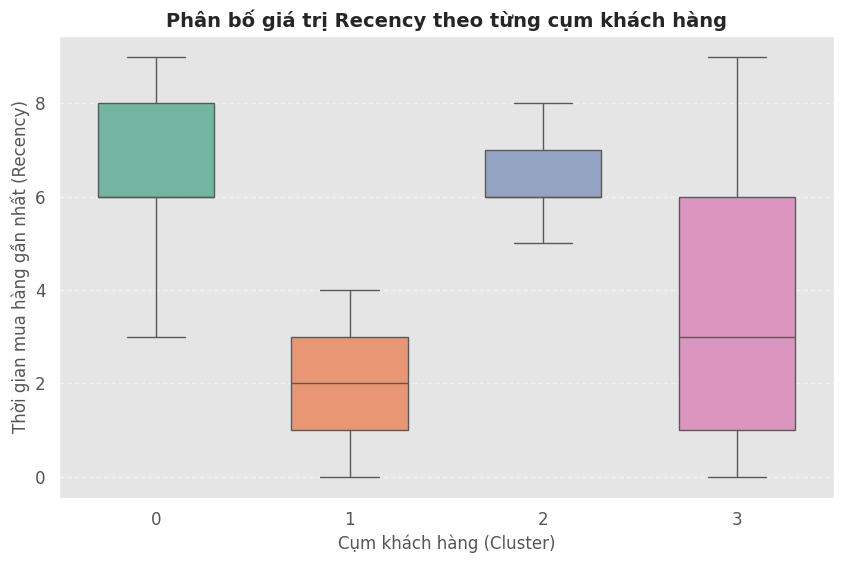

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Cluster',
    y='Recency',
    data=rfm_scores,
    palette='Set2',        # bảng màu giống biểu đồ Monetary
    showfliers=False,      # ẩn điểm ngoại lai
    width=0.6              # độ rộng hộp
)

plt.title('Phân bố giá trị Recency theo từng cụm khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Cụm khách hàng (Cluster)', fontsize=12)
plt.ylabel('Thời gian mua hàng gần nhất (Recency)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



Cluster
3    5653
0    4998
1    4595
2    4400
Name: count, dtype: int64


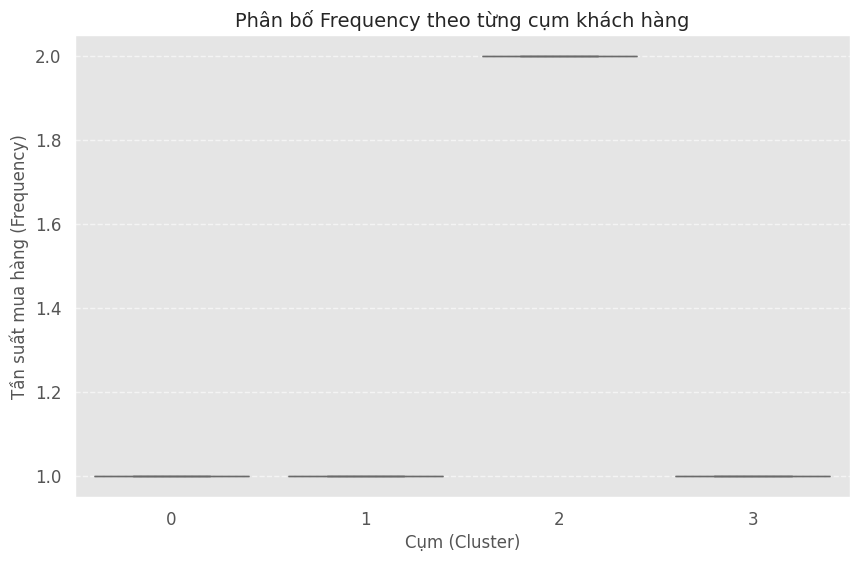

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra xem các cụm có đủ phân biệt không
print(rfm_scores['Cluster'].value_counts())

# Vẽ boxplot đẹp hơn bằng seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Cluster',
    y='Frequency',
    data=rfm_scores,
    palette='Set3',
    showfliers=False
)
plt.title('Phân bố Frequency theo từng cụm khách hàng', fontsize=14)
plt.xlabel('Cụm (Cluster)', fontsize=12)
plt.ylabel('Tần suất mua hàng (Frequency)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


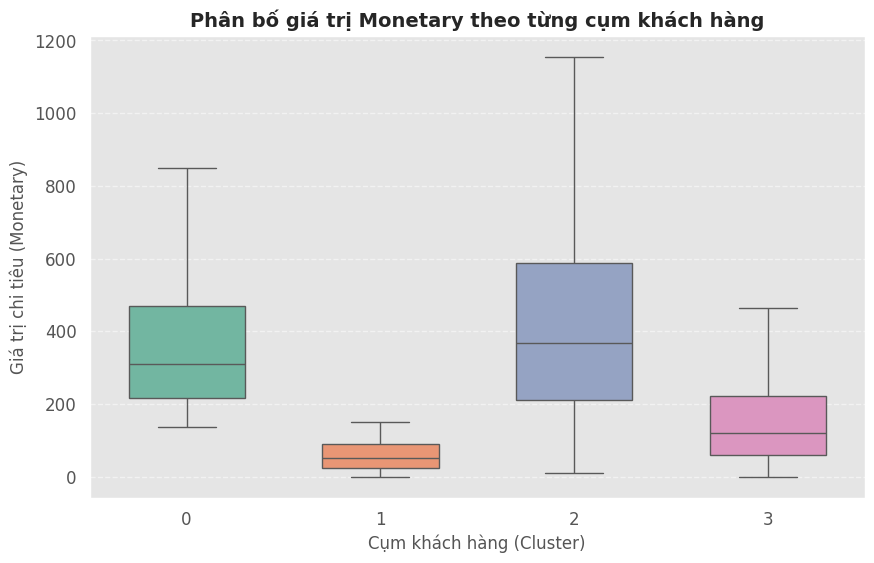

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Cluster',
    y='Monetary',
    data=rfm_scores,
    palette='Set2',
    showfliers=False,
    width=0.6
)

plt.title('Phân bố giá trị Monetary theo từng cụm khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Cụm khách hàng (Cluster)', fontsize=12)
plt.ylabel('Giá trị chi tiêu (Monetary)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



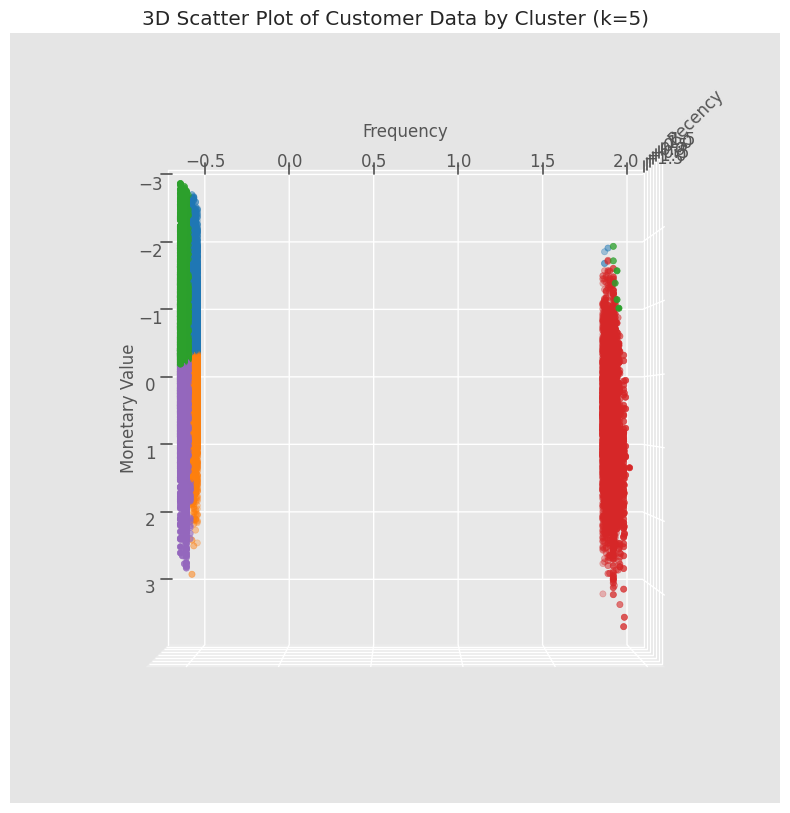

In [98]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Áp dụng KMeans với k=5
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_normalized_df = pd.DataFrame(rfm_normalized, columns=['Recency_transformed', 'Frequency_transformed', 'Monetary_transformed'])
rfm_normalized_df['Cluster'] = kmeans.fit_predict(
    rfm_normalized_df[['Monetary_transformed', 'Frequency_transformed', 'Recency_transformed']]
)

# Màu cho 5 cụm
cluster_colors = {
    0: '#1f77b4',  # Blue
    1: '#ff7f0e',  # Orange
    2: '#2ca02c',  # Green
    3: '#d62728',  # Red
    4: '#9467bd'   # Purple
}
colors = rfm_normalized_df['Cluster'].map(cluster_colors)

# Vẽ biểu đồ 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    rfm_normalized_df['Monetary_transformed'],
    rfm_normalized_df['Frequency_transformed'],
    rfm_normalized_df['Recency_transformed'],
    c=colors,
    marker='o'
)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data by Cluster (k=5)')

# 💡 Thêm dòng này để xoay góc nhìn
ax.view_init(elev=20, azim=90)  # elev: góc dọc, azim: góc ngang
ax.view_init(elev=90, azim=0)
plt.show()

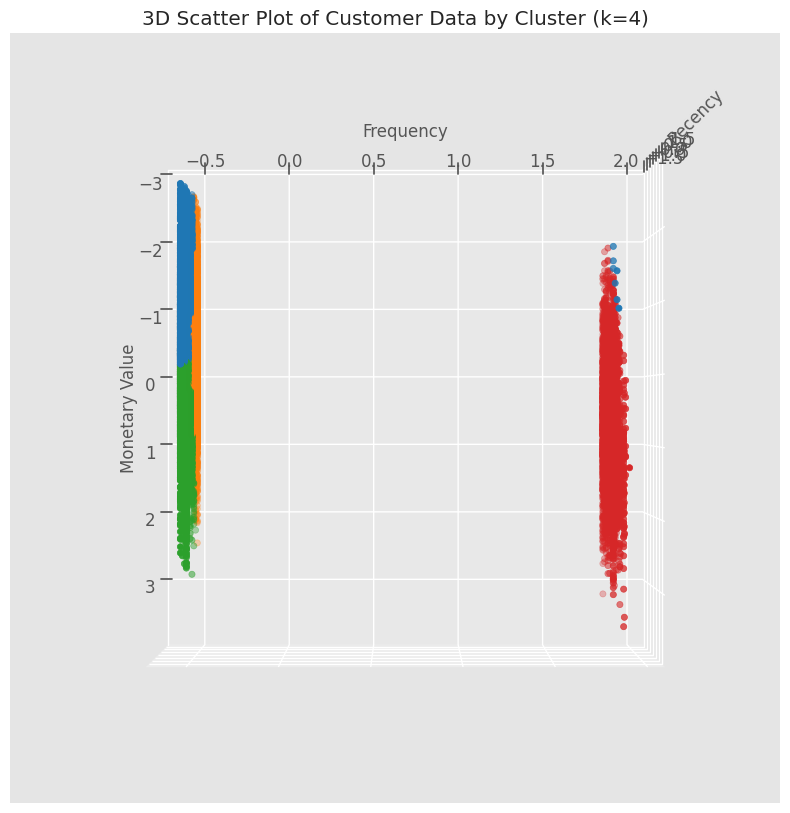

In [101]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Áp dụng KMeans với k=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_normalized_df = pd.DataFrame(
    rfm_normalized,
    columns=['Recency_transformed', 'Frequency_transformed', 'Monetary_transformed']
)
rfm_normalized_df['Cluster'] = kmeans.fit_predict(
    rfm_normalized_df[['Monetary_transformed', 'Frequency_transformed', 'Recency_transformed']]
)

# Màu cho 4 cụm
cluster_colors = {
    0: '#1f77b4',  # Blue
    1: '#ff7f0e',  # Orange
    2: '#2ca02c',  # Green
    3: '#d62728'   # Red
}
colors = rfm_normalized_df['Cluster'].map(cluster_colors)

# Vẽ biểu đồ 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    rfm_normalized_df['Monetary_transformed'],
    rfm_normalized_df['Frequency_transformed'],
    rfm_normalized_df['Recency_transformed'],
    c=colors,
    marker='o'
)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data by Cluster (k=4)')

# Tùy chỉnh góc nhìn
ax.view_init(elev=20, azim=90)
ax.view_init(elev=90, azim=0)
plt.show()


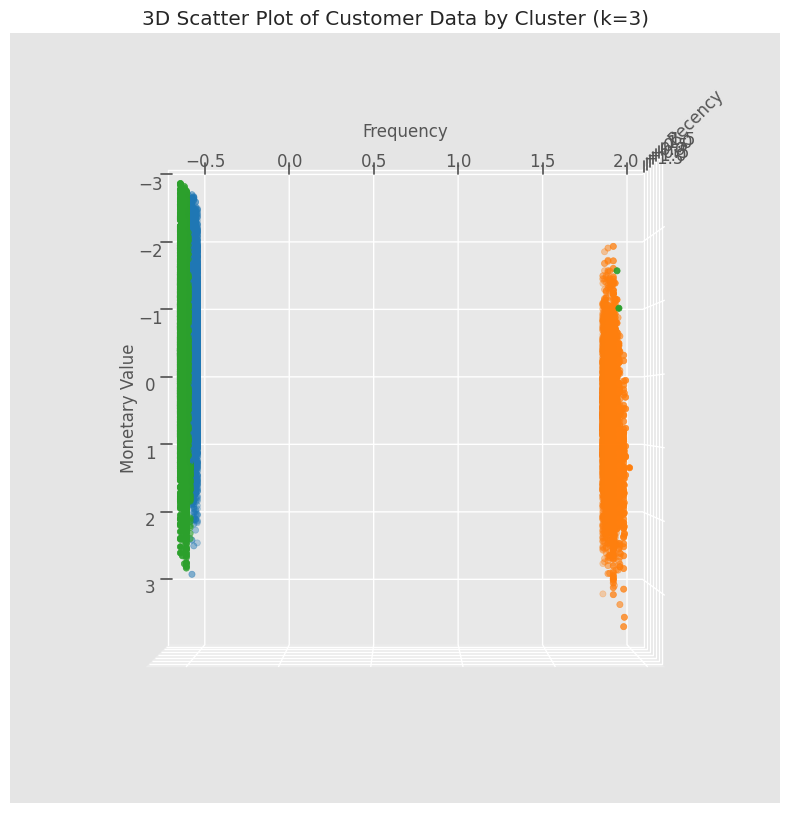

In [102]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Áp dụng KMeans với k=3
kmeans = KMeans(n_clusters=3, random_state=42)
rfm_normalized_df = pd.DataFrame(
    rfm_normalized,
    columns=['Recency_transformed', 'Frequency_transformed', 'Monetary_transformed']
)
rfm_normalized_df['Cluster'] = kmeans.fit_predict(
    rfm_normalized_df[['Monetary_transformed', 'Frequency_transformed', 'Recency_transformed']]
)

# Màu cho 3 cụm
cluster_colors = {
    0: '#1f77b4',  # Blue
    1: '#ff7f0e',  # Orange
    2: '#2ca02c'   # Green
}
colors = rfm_normalized_df['Cluster'].map(cluster_colors)

# Vẽ biểu đồ 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    rfm_normalized_df['Monetary_transformed'],
    rfm_normalized_df['Frequency_transformed'],
    rfm_normalized_df['Recency_transformed'],
    c=colors,
    marker='o'
)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data by Cluster (k=3)')

# Tùy chỉnh góc nhìn
ax.view_init(elev=20, azim=90)
ax.view_init(elev=90, azim=0)

plt.show()


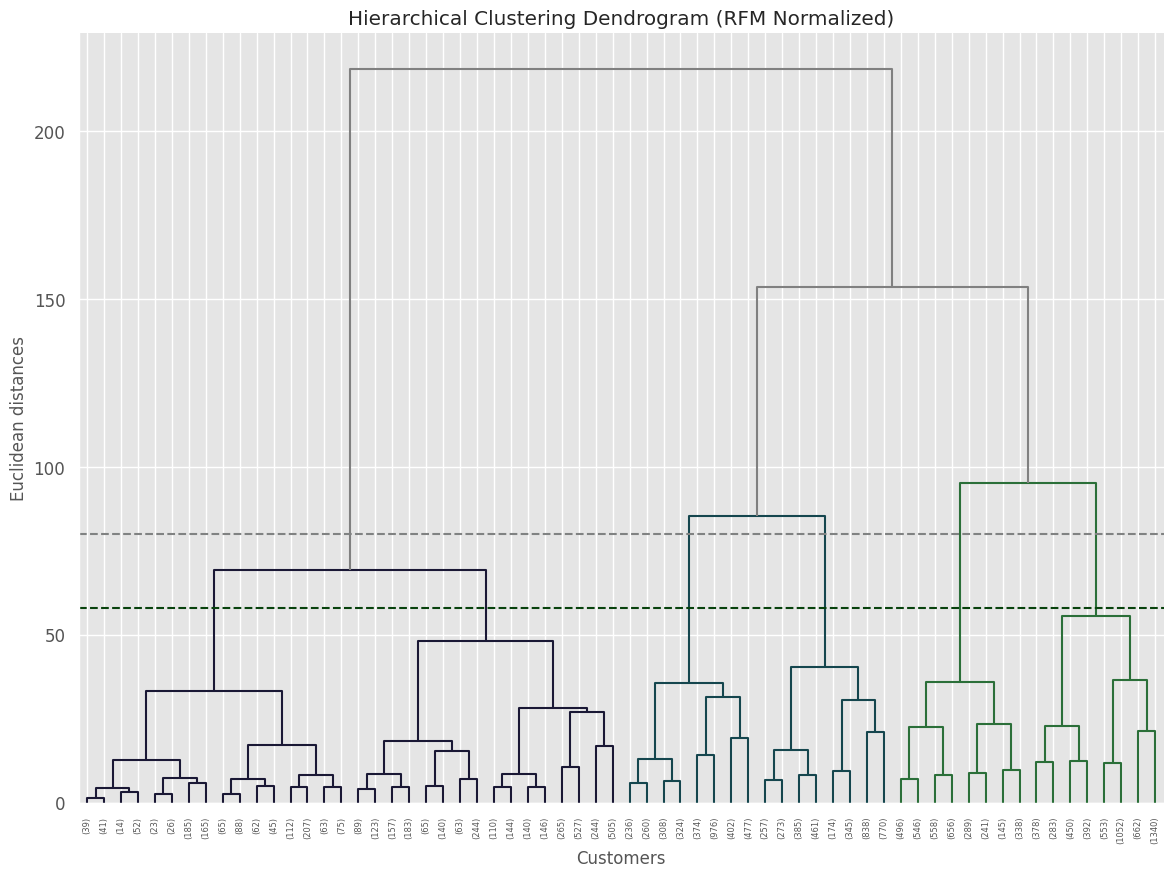

In [103]:
import numpy as np
import seaborn as sns
import scipy.cluster.hierarchy as sch
from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# --- Thiết lập style biểu đồ ---
# plt.style.use('seaborn-whitegrid') # Removed this line
cmap_den = sns.color_palette("cubehelix", 8).as_hex()
sch.set_link_color_palette(list(cmap_den))

# --- Dữ liệu RFM chuẩn hoá ---
RFM_s = rfm_normalized  # thống nhất biến tên với đoạn sau

# --- Huấn luyện mô hình Agglomerative ---
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(RFM_s)

# --- Hàm vẽ dendrogram từ model sklearn ---
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram = sch.dendrogram(linkage_matrix, **kwargs)
    return dendrogram

# --- Vẽ Dendrogram ---
plt.figure(figsize=(14, 10))
plt.title('Hierarchical Clustering Dendrogram (RFM Normalized)')
plot_dendrogram(model, truncate_mode='level', p=5, above_threshold_color='gray')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')

# --- Đường cắt xác định số cụm ---
plt.axhline(y=80, color='#808282', linestyle='--')
plt.axhline(y=58, color='#08420D', linestyle='--')

sns.despine(left=False, bottom=False)
plt.show()

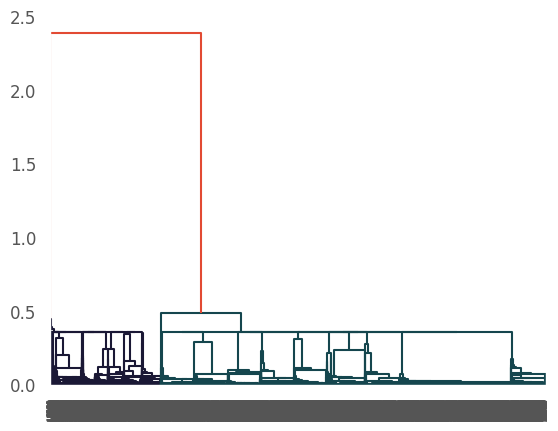

In [104]:
mergings = linkage(rfm_normalized, method="single", metric='euclidean')
dendrogram(mergings)
plt.show()

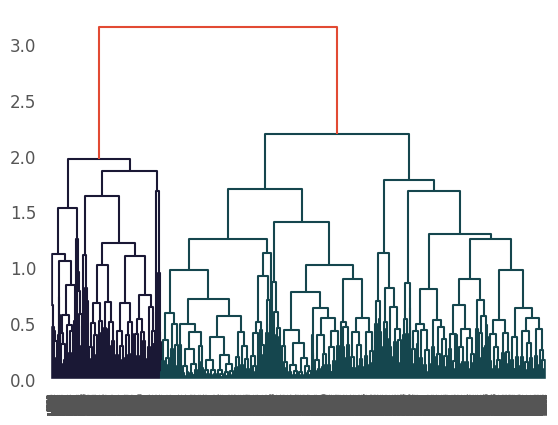

In [105]:
mergings = linkage(rfm_normalized, method="average", metric='euclidean')
dendrogram(mergings)
plt.show()

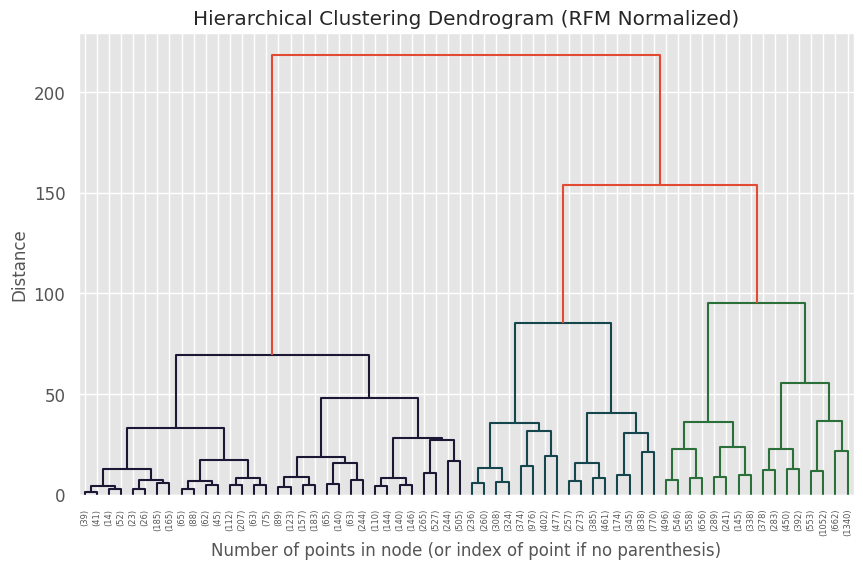

In [106]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

# --- Hàm vẽ dendrogram (giữ nguyên như bạn có) ---
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


# --- Áp dụng cho tập RFM chuẩn hóa ---
X = rfm_normalized  # Dùng dữ liệu của bạn

# distance_threshold=0 -> tính toàn bộ cây phân cấp
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

# Huấn luyện mô hình
model = model.fit(X)

# --- Vẽ Dendrogram ---
plt.figure(figsize=(10, 6))
plt.title("Hierarchical Clustering Dendrogram (RFM Normalized)")
plot_dendrogram(model, truncate_mode="level", p=5)  # p=3: hiển thị 3 cấp cao nhất
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()

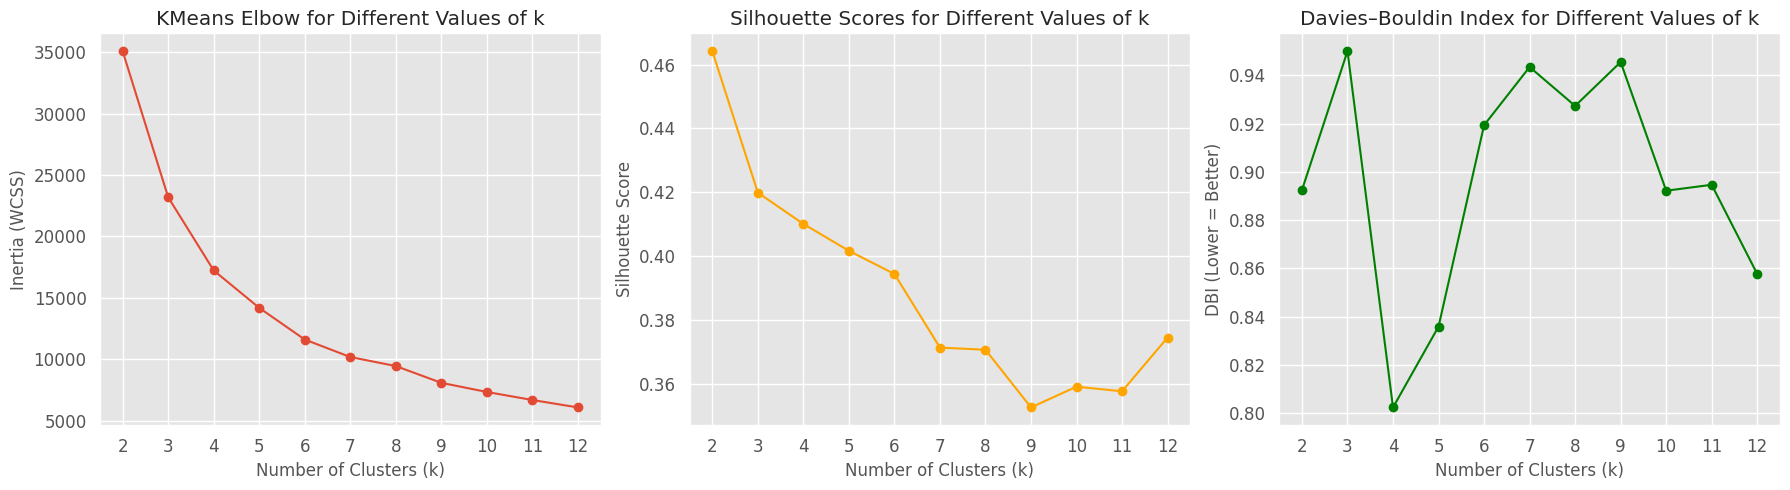

In [107]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

max_k = 12

inertia = []
silhouette_scores = []
dbi_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    # Khởi tạo mô hình KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(rfm_normalized)

    # Tính các chỉ số đánh giá
    sil_score = silhouette_score(rfm_normalized, cluster_labels)
    dbi = davies_bouldin_score(rfm_normalized, cluster_labels)

    # Lưu kết quả
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)
    dbi_scores.append(dbi)

# -------------------------------
# Vẽ biểu đồ đánh giá
plt.figure(figsize=(18, 5))

# Biểu đồ Elbow
plt.subplot(1, 3, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Elbow for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.grid(True)

# Biểu đồ Silhouette
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

# Biểu đồ Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(k_values, dbi_scores, marker='o', color='green')
plt.title('Davies–Bouldin Index for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('DBI (Lower = Better)')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()


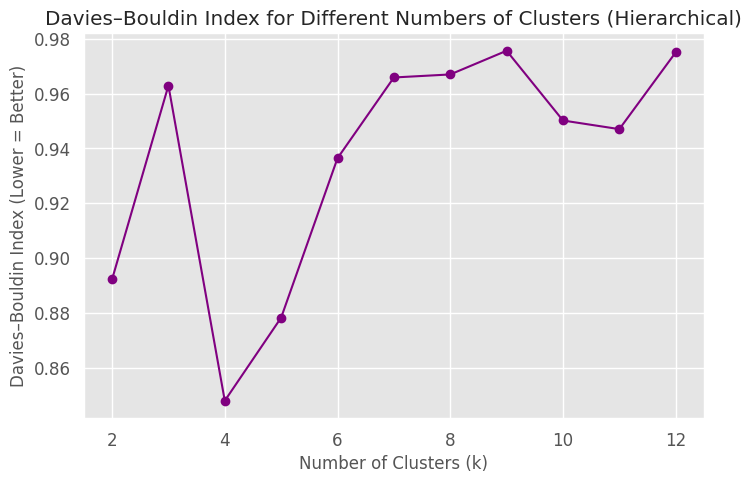

In [108]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt

max_k = 12
dbi_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    # Huấn luyện mô hình với số cụm k
    model = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = model.fit_predict(rfm_normalized)

    # Tính Davies–Bouldin Index
    dbi = davies_bouldin_score(rfm_normalized, labels)
    dbi_scores.append(dbi)

# --- Vẽ biểu đồ DBI ---
plt.figure(figsize=(8, 5))
plt.plot(k_values, dbi_scores, marker='o', color='purple')
plt.title('Davies–Bouldin Index for Different Numbers of Clusters (Hierarchical)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies–Bouldin Index (Lower = Better)')
plt.grid(True)
plt.show()


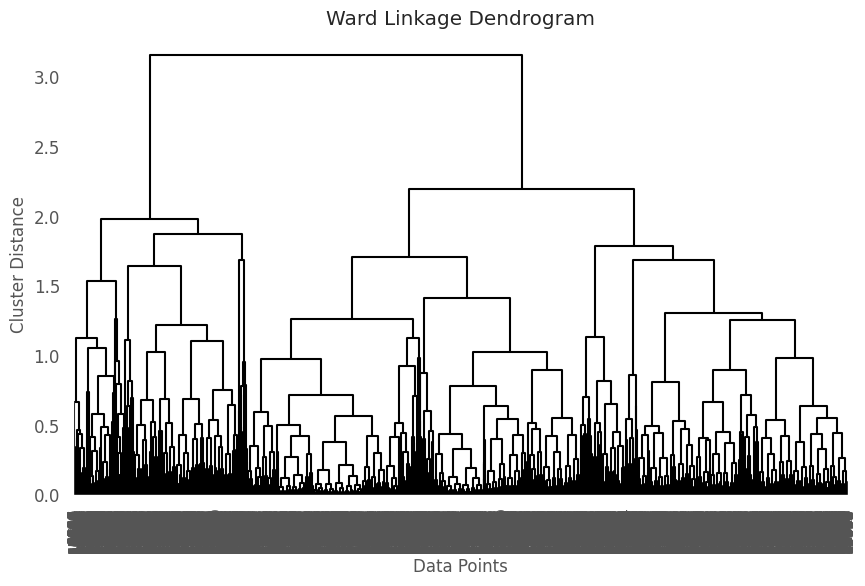

In [111]:
#Plot the dendrogram (linkage method 'ward')
plt.figure(figsize=(10,6))
d_ward = dendrogram(mergings, leaf_rotation=90, leaf_font_size=10, link_color_func=lambda x: 'black')
plt.title('Ward Linkage Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Cluster Distance')

#Plot a horizontal line indicating the clustering point
plt.axhline(y=125000, color='r', linestyle='--')

In [113]:
#Cut the dendrogram to form clusters
num_clusters = 4

#Add cluster membership to the original data
cluster_labels = cut_tree(mergings, n_clusters=num_clusters).flatten()

In [115]:
#Fit agglomerative clustering
ac = AgglomerativeClustering(n_clusters= num_clusters, linkage='ward')
cluster_labels = ac.fit_predict(rfm_normalized)

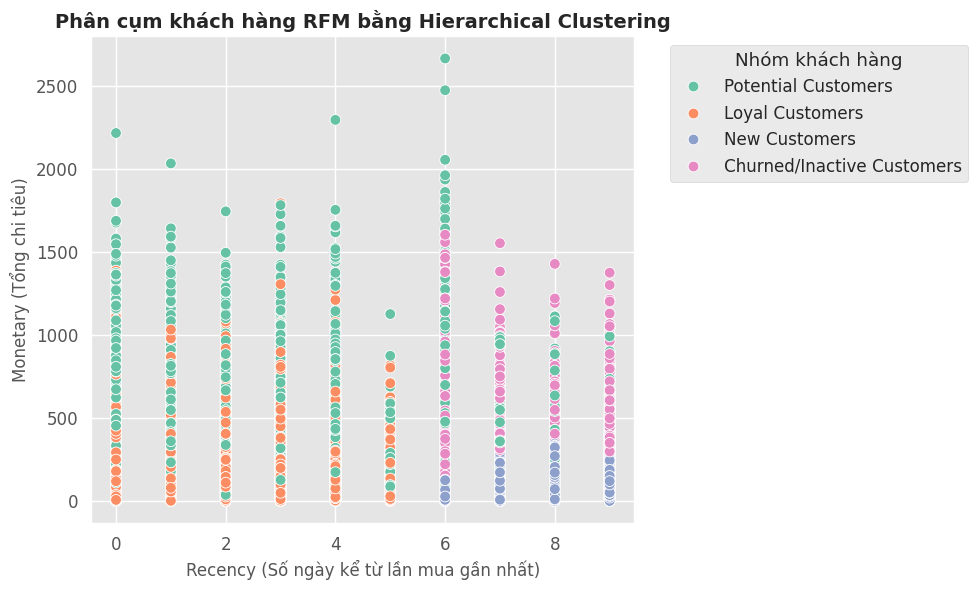

Tóm tắt trung bình từng cụm khách hàng:
                            Recency  Frequency  Monetary
Cluster_Label                                           
Churned/Inactive Customers      6.4        1.0     416.0
Loyal Customers                 2.1        1.0     181.2
New Customers                   7.3        1.0      95.3
Potential Customers             3.1        2.2     441.3


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


# --- 2️⃣ Phân cụm phân cấp ---
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
rfm['Cluster'] = hc.fit_predict(rfm_normalized)

# --- 3️⃣ Gán nhãn cho từng cụm ---
# ⚠️ Gợi ý: bạn có thể đảo thứ tự các nhãn tùy vào kết quả trung bình từng cụm
cluster_labels = {
    0: 'Loyal Customers',               # Khách hàng trung thành
    1: 'Potential Customers',           # Khách hàng tiềm năng
    2: 'New Customers',                 # Khách hàng mới
    3: 'Churned/Inactive Customers'     # Khách hàng thụ động hoặc rời bỏ
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# --- 4️⃣ Vẽ biểu đồ trực quan hoá cụm ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster_Label',
    palette='Set2',
    s=60
)

plt.title('Phân cụm khách hàng RFM bằng Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Số ngày kể từ lần mua gần nhất)')
plt.ylabel('Monetary (Tổng chi tiêu)')
plt.legend(title='Nhóm khách hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5️⃣ Xem đặc điểm từng cụm ---
cluster_summary = rfm.groupby('Cluster_Label')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print("Tóm tắt trung bình từng cụm khách hàng:")
print(cluster_summary)